# Домашнее задание: RAG по созвездиям + Image-RAG

**Часть 1 (7 баллов):** текстовый RAG по статьям Wikipedia о созвездиях с Qwen.

**Часть 2 (3 балла):** мультимодальный RAG, который отвечает на вопросы по картинке через BLIP captioning + текстовый RAG.

**Общая задача:** построить RAG систему на основе статей Wiki, которая сможет отвечать на вопросы о созвездиях, а также о различных изображениях, где встречаются отсылки к созвездиям. В идеале система должна быть способна отвечать как на специфичные вопросы, касающиеся размера, количества звезд в созвездии, так и на простые (например, "Какие созвездия включают в себя изображения человека?")

Ссылка для сдачи ДЗ: https://forms.gle/NH7m25G6X9qYX7j38

## 0. Установка зависимостей

In [3]:
!pip install -q langchain langchain-community langchain-huggingface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [4]:
!pip install -q wikipedia-api

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.2/129.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 9.7 MB/s eta 0:00:00


In [5]:
!pip install -q chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sou

In [ ]:
#!pip install -q 'numpy<2'
!pip install -q wikipedia-api
!pip install -q langchain langchain-community langchain-huggingface
!pip install -q chromadb
!pip install -q sentence-transformers
!pip install -q transformers accelerate
!pip install -q pillow

import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 939.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.2/129.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━

In [1]:
import os
import re
import warnings  # чтобы заглушить лишние предупреждения
import logging  # для логирования MultiQueryRetriever
from typing import List, Dict, Tuple
from pprint import pprint

warnings.filterwarnings('ignore')
# Отключаем телеметрию ChromaDB
os.environ['ANONYMIZED_TELEMETRY'] = 'False'
# Отключаем параллелизм токенизаторов, чтобы не было предупреждений после fork()
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

---
# Часть 1. Текстовый RAG по созвездиям (7 баллов)

Мы построим RAG-систему, которая отвечает на вопросы о созвездиях, опираясь на статьи Wikipedia.

Pipeline стандартный: **парсинг → чанкинг → эмбеддинги → векторное хранилище → retrieval → генерация**.

## 1.1. Парсинг Wikipedia (1 балл)

Необходимо скачать английские статьи через `wikipedia-api` о созвездиях. API сам отдаёт чистый текст без вики-разметки.


In [2]:
import wikipediaapi  # клиент к Wikipedia API

# Создаём клиент с user-agent, Wikipedia требует его указывать
wiki = wikipediaapi.Wikipedia(
    user_agent='RAG-Homework/1.0 (educational)',  # идентификатор
    language='en',  # английская Wikipedia
    extract_format=wikipediaapi.ExtractFormat.WIKI  # вернёт plain-text без HTML
)


CONSTELLATIONS = [
    "Orion (constellation)",
    "Scorpius",
    "Ursa Major",
    "Cassiopeia (constellation)",
    "Leo (constellation)",
    "Cygnus (constellation)",
    "Gemini (constellation)",
    "Aquarius (constellation)",
    "Perseus (constellation)",
    "Virgo (constellation)",
    "Andromeda (constellation)",
    "Pegasus (constellation)",
    "Hercules (constellation)",
    "Lyra",
    "Centaurus",
    "Crux",
    "Aries (constellation)",
    "Taurus (constellation)",
    "Cancer (constellation)",
    "Sagittarius (constellation)",
    "Capricornus",
    "Pisces (constellation)",
    "Libra (constellation)"
]

def fetch_wiki_article(page_title: str) -> str:
    """Скачивает текст статьи Wikipedia и аккуратно обрабатывает ошибки."""
    # Запрашиваем страницу
    page = wiki.page(page_title)
    # Проверяем существование страницы
    if not page.exists():
        # Прописываем исключение
        raise ValueError(f"Страница '{page_title}' не найдена в Wikipedia")
    text = page.text
    # Убираем повторяющиеся переводы строк
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text

#ВАШ КОД
# Качаем статьи по всем созвездиям с помощью функции fetch_wiki_articles, сохраняем в словарь articles
articles = {}
for title in CONSTELLATIONS:
    try:
        clean_key = re.sub(r'\s*\(constellation\)', '', title).strip()
        articles[clean_key] = fetch_wiki_article(title)
    except ValueError as e:
        print(f"Ошибка при загрузке {title}: {e}")

print(f"Успешно загружено статей: {len(articles)}")

Успешно загружено статей: 23


In [3]:
# Смотрим первые 500 символов каждой статьи, чтобы удостовериться, что все верно
for name, text in articles.items():
    print(f'=== {name} ===')
    print(text[:500])
    print('...\n')

=== Orion ===
Orion is a prominent set of stars visible during winter in the northern celestial hemisphere. It is one of the 88 modern constellations; it was among the 48 constellations listed by the 2nd-century AD astronomer Ptolemy. It is named after a hunter in Greek mythology.
Orion is most prominent during winter evenings in the Northern Hemisphere, as are five other constellations that have stars in the Winter Hexagon asterism. Orion's two brightest stars, Rigel (β) and Betelgeuse (α), are both among th
...

=== Scorpius ===
Scorpius is a zodiac constellation located in the Southern celestial hemisphere, where it sits near the center of the Milky Way, between Libra to the west and Sagittarius to the east. Scorpius is an ancient constellation whose recognition predates Greek culture; it is one of the 48 constellations identified by the Greek astronomer Ptolemy in the second century.

Features
Stars
Scorpius contains many bright stars, including Antares (α Sco), "rival of Mars," so

## 1.2. Сравнение двух стратегий чанкования (3 балла)

В RAG способ разбиения текста на куски (чанки) напрямую влияет на качество retrieval. Сравним два сплиттера из LangChain:

- **`CharacterTextSplitter`** - режет по одному разделителю (по умолчанию `\n\n`). Простой, но может выдать слишком длинные или слишком короткие куски, если разделитель распределён неравномерно.
- **`RecursiveCharacterTextSplitter`** - пробует разделители по списку (от `\n\n` к `\n` к ` ` к ``). Это даёт более ровный размер чанков и сохраняет смысловые границы.

Необходимо в этой части:
*   дописать функцию для подсчета простой статистики для сравнения чанкеров - 0,5 балла
*   проанализировать 2 вида чанкеров с разными параметрами и ответить на поставленные вопросы- 2 балла
*   реализовать отдельную функцию для сравнения чанкеров - 0,5 балла





In [3]:
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter
# Параметры одинаковые для обоих, чтобы сравнение было честным
CHUNK_SIZE = 800  # целевой размер чанка в символах
CHUNK_OVERLAP = 100  # перекрытие помогает не терять контекст на границах

char_splitter = CharacterTextSplitter(
    separator='\n\n',  # единственный разделитель
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len,  # считаем длину в символах, а не в токенах
)

recursive_splitter = RecursiveCharacterTextSplitter(
    separators=['\n\n', '\n', '. ', ' ', ''],  # от смысловых границ к посимвольным
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len,
)

# Берём для сравнения текст про Орион
sample_text = articles['Orion']

# Применяем оба сплиттера к одному и тому же тексту
char_chunks = char_splitter.split_text(sample_text)
recursive_chunks = recursive_splitter.split_text(sample_text)

# Напишите функцию для подсчета простой статистики: количество кусков, средняя/мин/макс длина
def chunk_stats(chunks: List[str]) -> Dict[str, float]:
    """Подсчитывает базовую статистику длин чанков."""
    lengths = [len(c) for c in chunks]
    return {
        "count": len(lengths),
        "mean": sum(lengths) / len(lengths),
        "min": min(lengths),
        "max": max(lengths)
    }

print('CharacterTextSplitter:', chunk_stats(char_chunks))
print('RecursiveCharacterTextSplitter:', chunk_stats(recursive_chunks))

CharacterTextSplitter: {'count': 23, 'mean': 1118.4782608695652, 'min': 370, 'max': 3029}
RecursiveCharacterTextSplitter: {'count': 51, 'mean': 503.96078431372547, 'min': 4, 'max': 797}


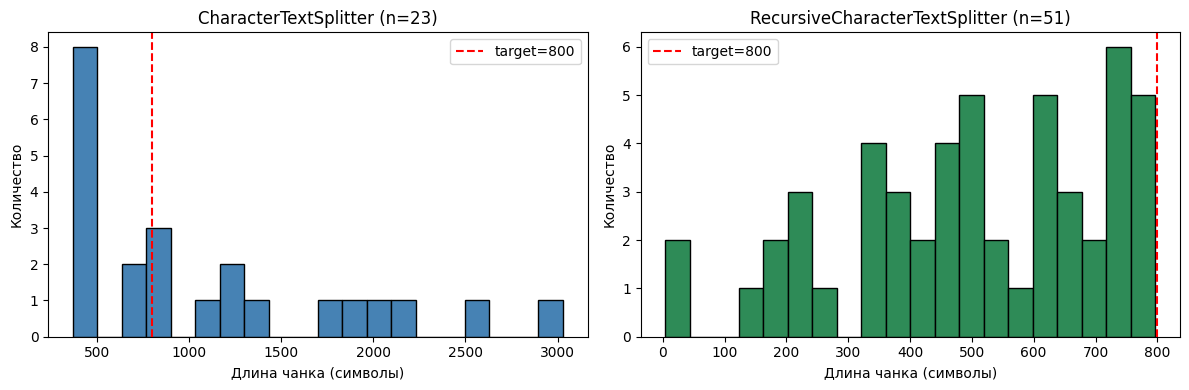

In [9]:
# Визуальное сравнение: рисуем гистограмму длин для обоих сплиттеров рядом
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма длин для CharacterTextSplitter
axes[0].hist([len(c) for c in char_chunks], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title(f'CharacterTextSplitter (n={len(char_chunks)})')
axes[0].set_xlabel('Длина чанка (символы)')
axes[0].set_ylabel('Количество')
# Вертикальная линия на целевом размере. Так мы увидим, насколько сплиттер от него отклоняется
axes[0].axvline(CHUNK_SIZE, color='red', linestyle='--', label=f'target={CHUNK_SIZE}')
axes[0].legend()

# Гистограмма для RecursiveCharacterTextSplitter
axes[1].hist([len(c) for c in recursive_chunks], bins=20, color='seagreen', edgecolor='black')
axes[1].set_title(f'RecursiveCharacterTextSplitter (n={len(recursive_chunks)})')
axes[1].set_xlabel('Длина чанка (символы)')
axes[1].set_ylabel('Количество')
axes[1].axvline(CHUNK_SIZE, color='red', linestyle='--', label=f'target={CHUNK_SIZE}')
axes[1].legend()

plt.tight_layout()
plt.show()

### TO DO

Поэкспериментируйте со сплиттерами. В ячейке ниже сравните, как меняется распределение длин чанков при разных значениях `chunk_size` (например, 400 vs 800 vs 1600) и `chunk_overlap` (0 vs 100 vs 300).

**Ответьте на следующие вопросы:**
1. Какой сплиттер вы бы выбрали для дальнейшей работы и почему?
2. При каких `chunk_size` и `chunk_overlap` распределение выглядит самым ровным?
3. Что произойдёт с retrieval, если поставить `chunk_size=100`? А `chunk_size=4000`?

In [8]:
import logging

logging.getLogger('langchain_text_splitters.base').setLevel(logging.ERROR)

*Объеденим все выше в одну функцию для удобного вызова*

In [14]:
import matplotlib.pyplot as plt

def plot_splitter_comparison(
    text: str,
    chunk_size: int,
    chunk_overlap: int,
    sample_name: str = "Sample"
):
    """
    Сравнивает CharacterTextSplitter и RecursiveCharacterTextSplitter
    для заданных параметров и рисует гистограммы распределения длин чанков.
    """
    # Инициализируем сплиттеры с текущими параметрами
    char_splitter = CharacterTextSplitter(
        separator='\n\n',
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
    )
    recursive_splitter = RecursiveCharacterTextSplitter(
        separators=['\n\n', '\n', '. ', ' ', ''],
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
    )

    # Разбиваем текст
    char_chunks = char_splitter.split_text(text)
    rec_chunks = recursive_splitter.split_text(text)

    # Считаем статистику
    char_stats = chunk_stats(char_chunks)
    rec_stats = chunk_stats(rec_chunks)

    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"Сравнение сплиттеров: chunk_size={chunk_size}, overlap={chunk_overlap} ({sample_name})")

    # CharacterTextSplitter
    axes[0].hist([len(c) for c in char_chunks], bins=20, color='steelblue', edgecolor='black', alpha=0.8)
    axes[0].axvline(chunk_size, color='red', linestyle='--', linewidth=1.5, label=f'target={chunk_size}')
    axes[0].axvline(char_stats['mean'], color='orange', linestyle=':', linewidth=1.5, label=f"mean={char_stats['mean']:.0f}")
    axes[0].set_title(f"CharacterTextSplitter\nn={char_stats['count']}, min={char_stats['min']}, max={char_stats['max']}")
    axes[0].set_xlabel('Длина чанка (символы)')
    axes[0].set_ylabel('Количество')
    axes[0].legend(fontsize=8)
    axes[0].grid(axis='y', alpha=0.3)

    # RecursiveCharacterTextSplitter
    axes[1].hist([len(c) for c in rec_chunks], bins=20, color='seagreen', edgecolor='black', alpha=0.8)
    axes[1].axvline(chunk_size, color='red', linestyle='--', linewidth=1.5, label=f'target={chunk_size}')
    axes[1].axvline(rec_stats['mean'], color='orange', linestyle=':', linewidth=1.5, label=f"mean={rec_stats['mean']:.0f}")
    axes[1].set_title(f"RecursiveCharacterTextSplitter\nn={rec_stats['count']}, min={rec_stats['min']}, max={rec_stats['max']}")
    axes[1].set_xlabel('Длина чанка (символы)')
    axes[1].set_ylabel('Количество')
    axes[1].legend(fontsize=8)
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


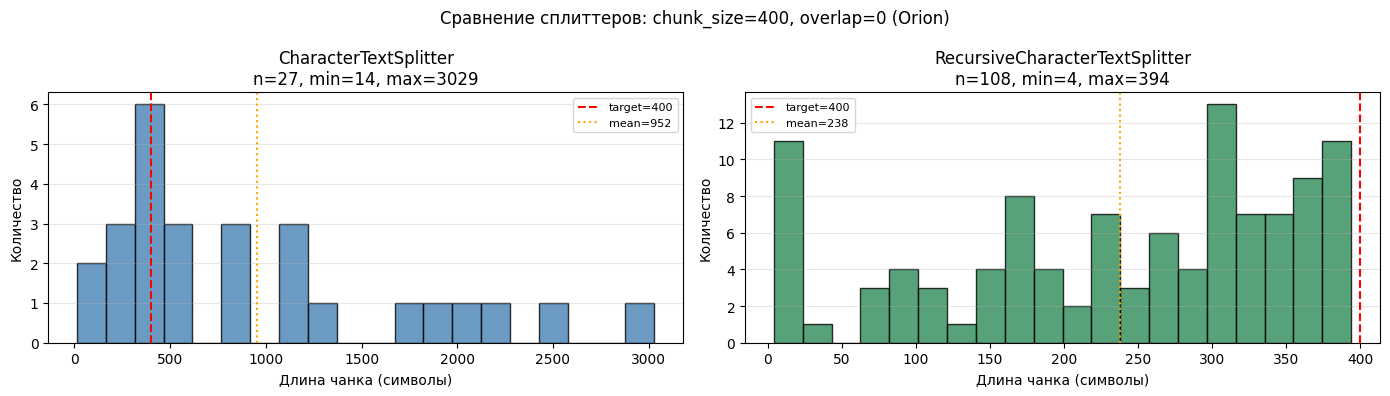

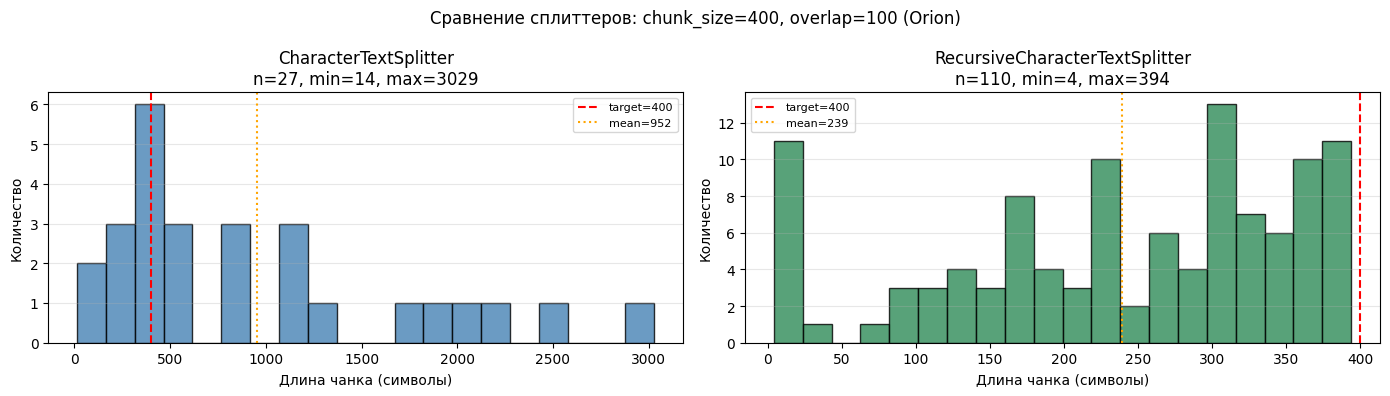

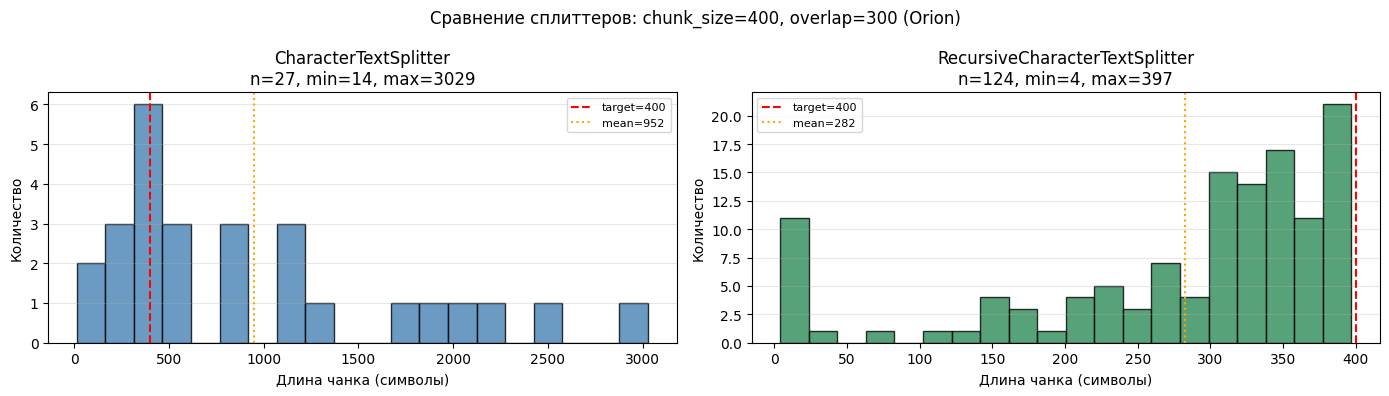

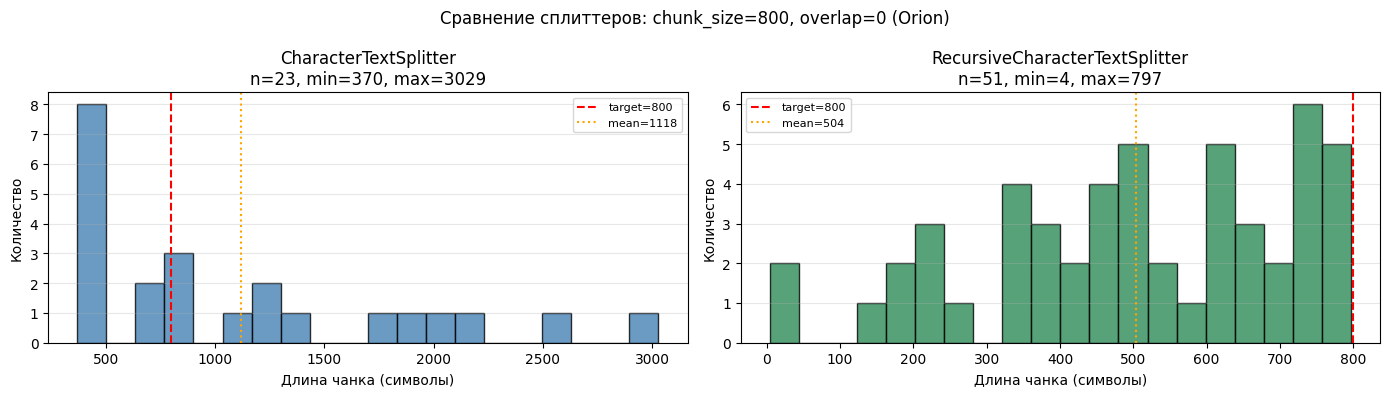

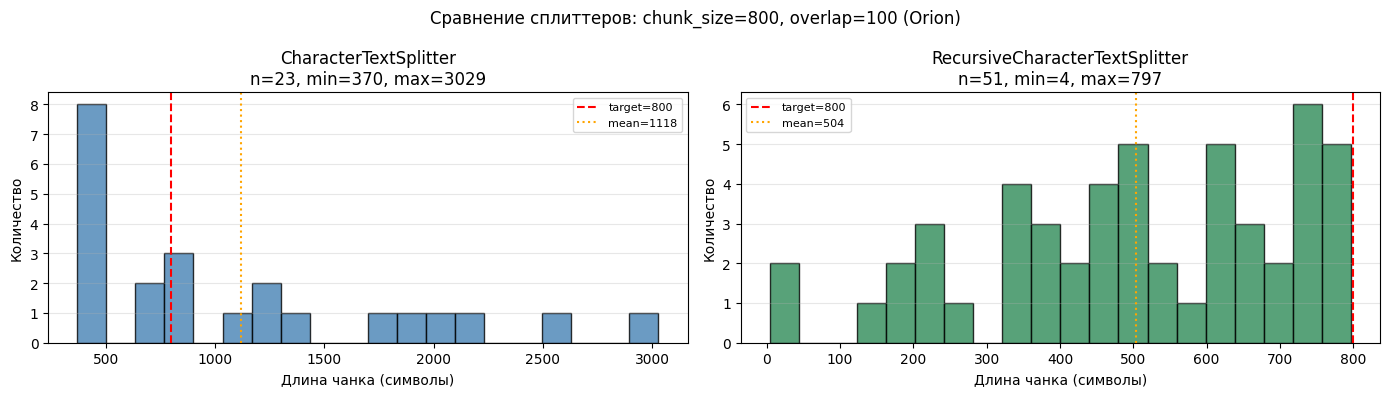

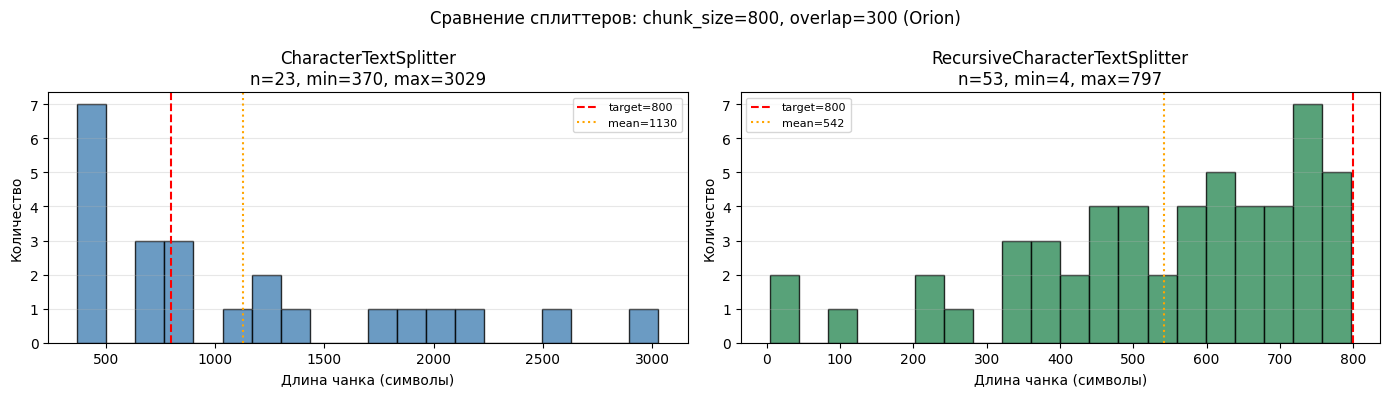

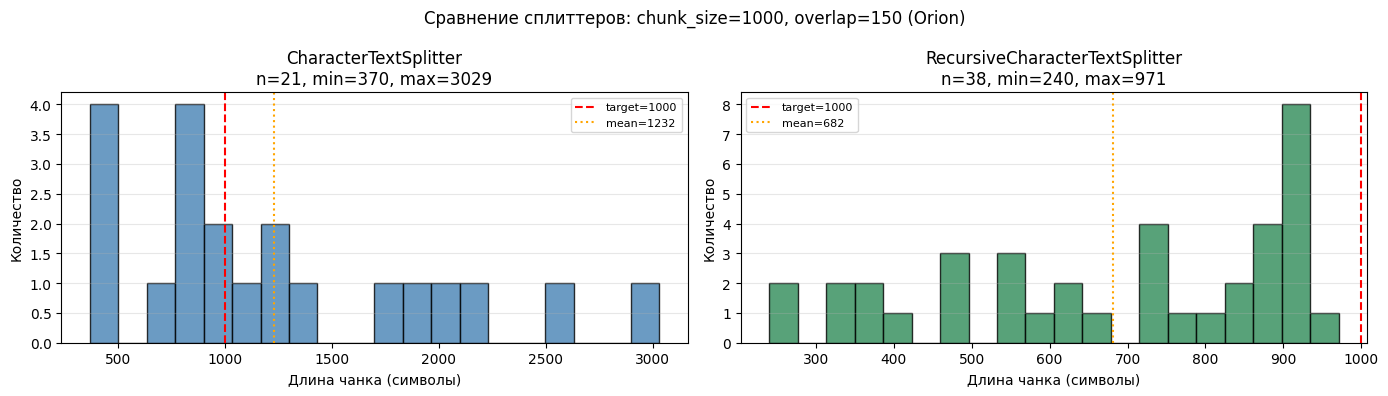

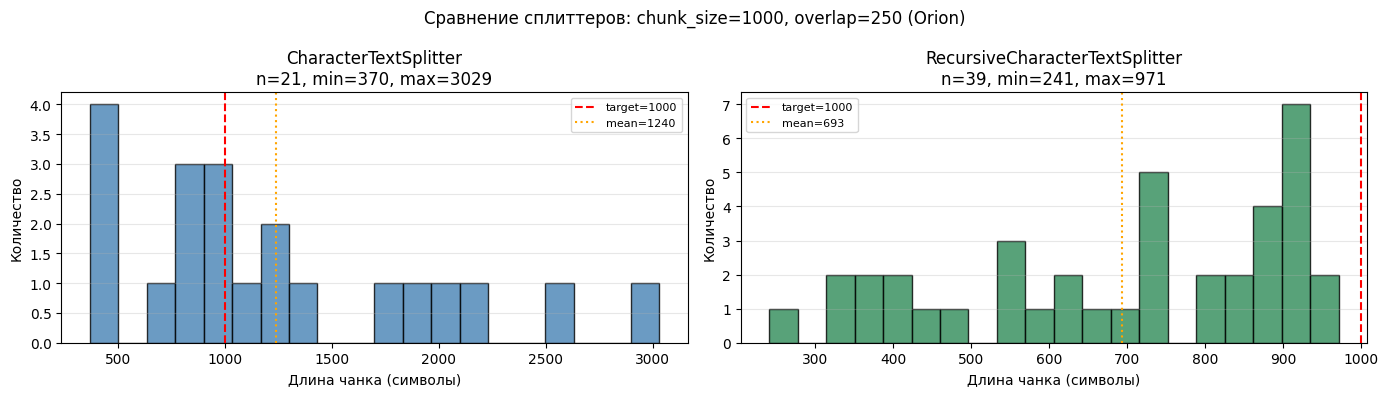

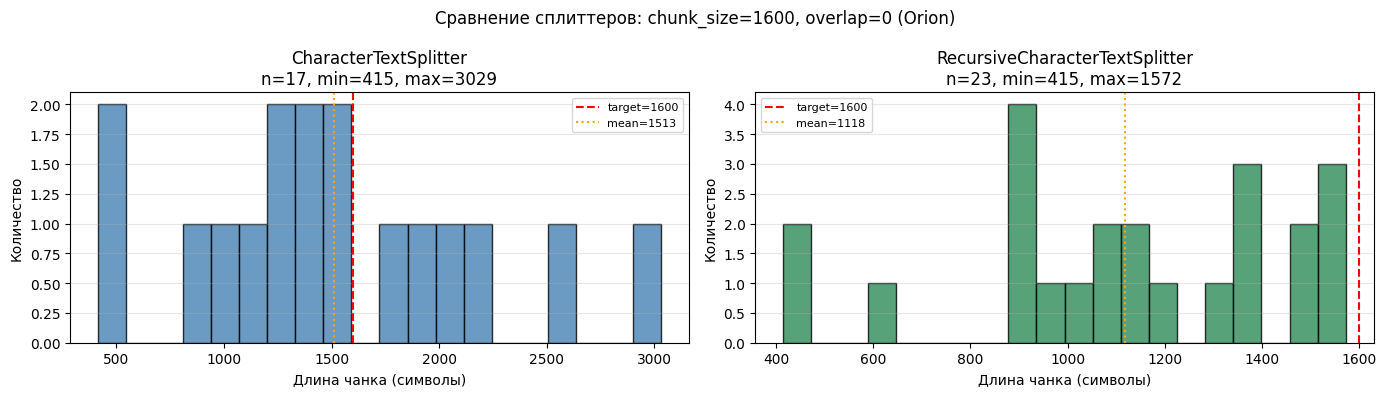

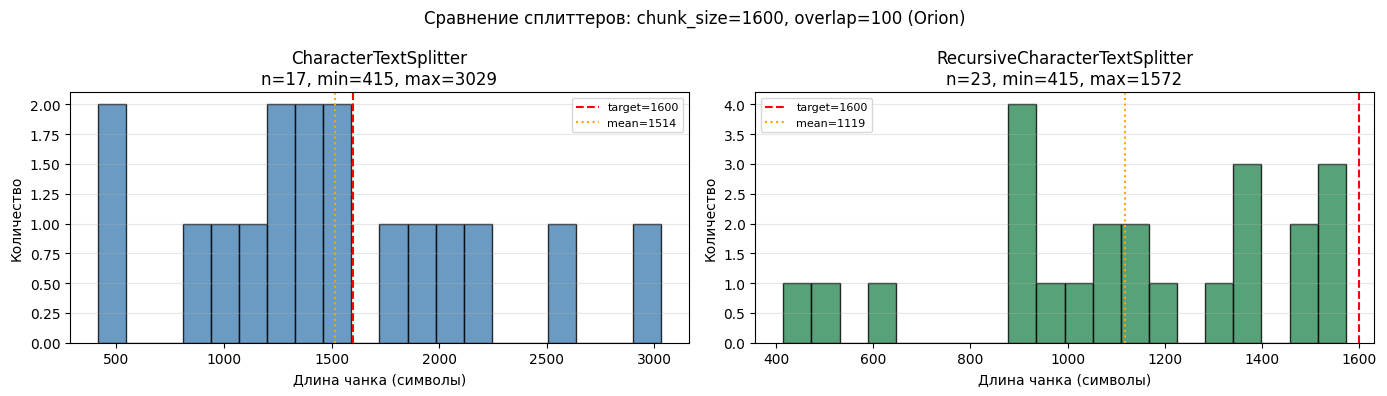

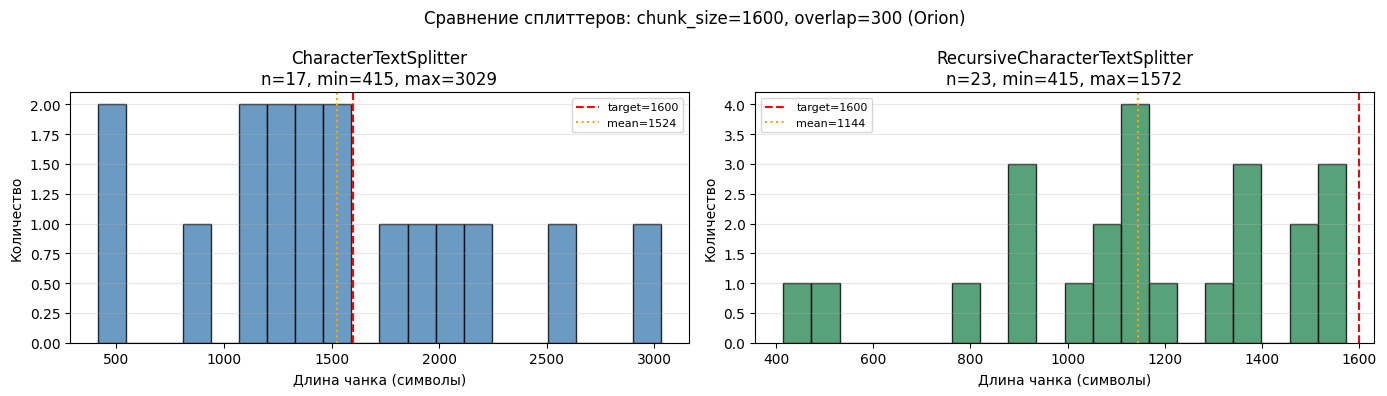

In [19]:
params_to_test = [
    {"chunk_size": 400, "chunk_overlap": 0},
    {"chunk_size": 400, "chunk_overlap": 100},
    {"chunk_size": 400, "chunk_overlap": 300},
    {"chunk_size": 800, "chunk_overlap": 0},
    {"chunk_size": 800, "chunk_overlap": 100},
    {"chunk_size": 800, "chunk_overlap": 300},
    {"chunk_size": 1000, "chunk_overlap": 150},
    {"chunk_size": 1000, "chunk_overlap": 250},
    {"chunk_size": 1600, "chunk_overlap": 0},
    {"chunk_size": 1600, "chunk_overlap": 100},
    {"chunk_size": 1600, "chunk_overlap": 300},
]

for params in params_to_test:
    plot_splitter_comparison(
        text=articles['Orion'],
        chunk_size=params["chunk_size"],
        chunk_overlap=params["chunk_overlap"],
        sample_name="Orion"
    )

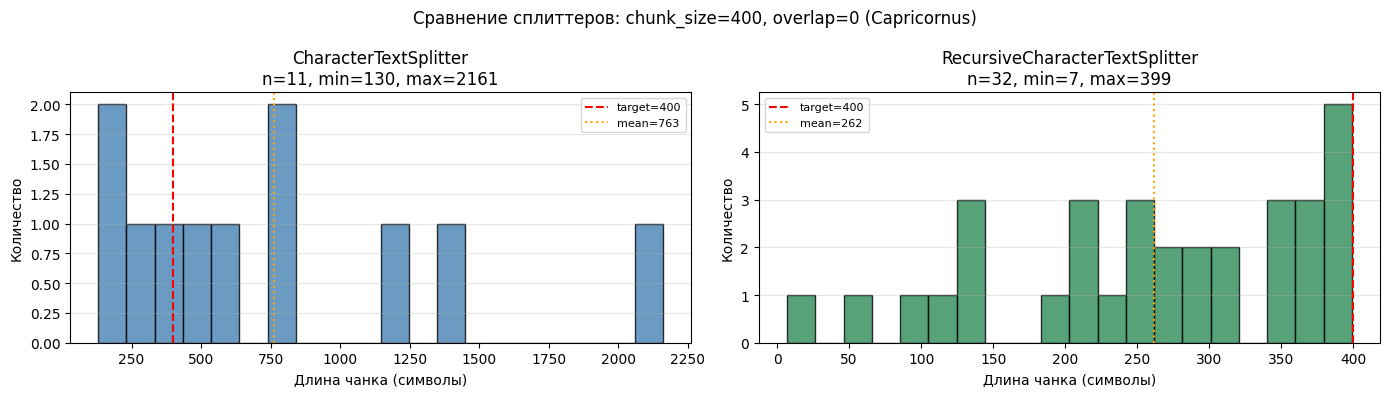

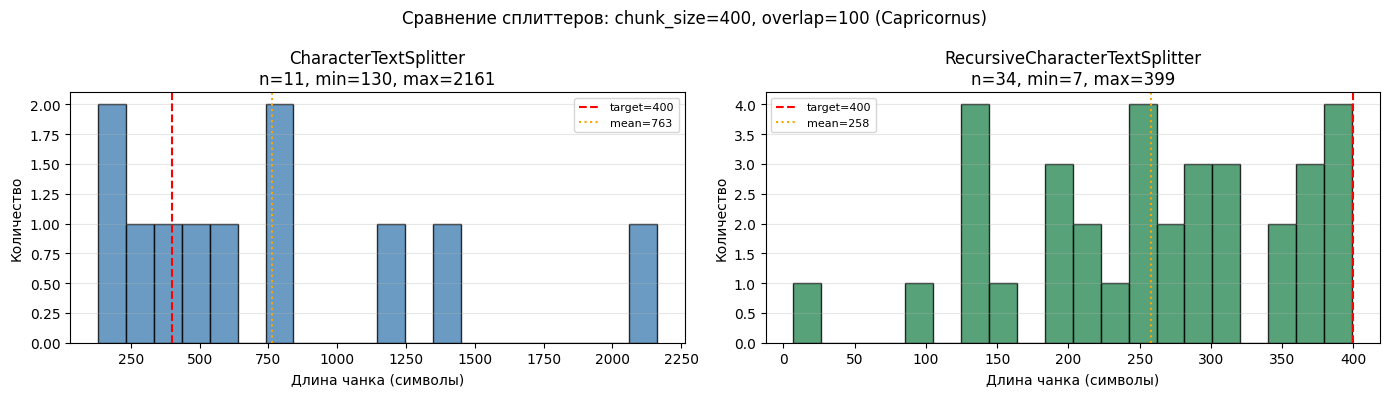

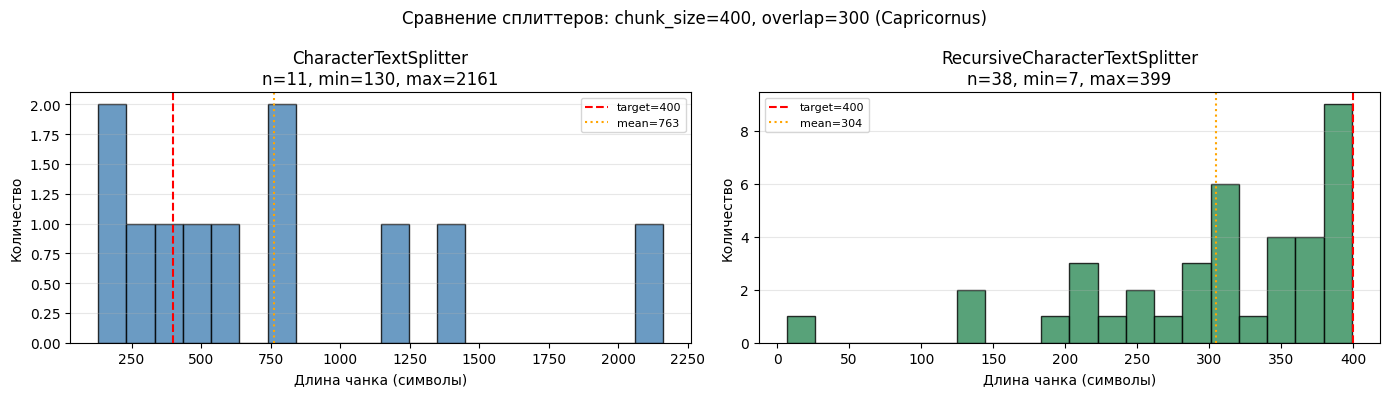

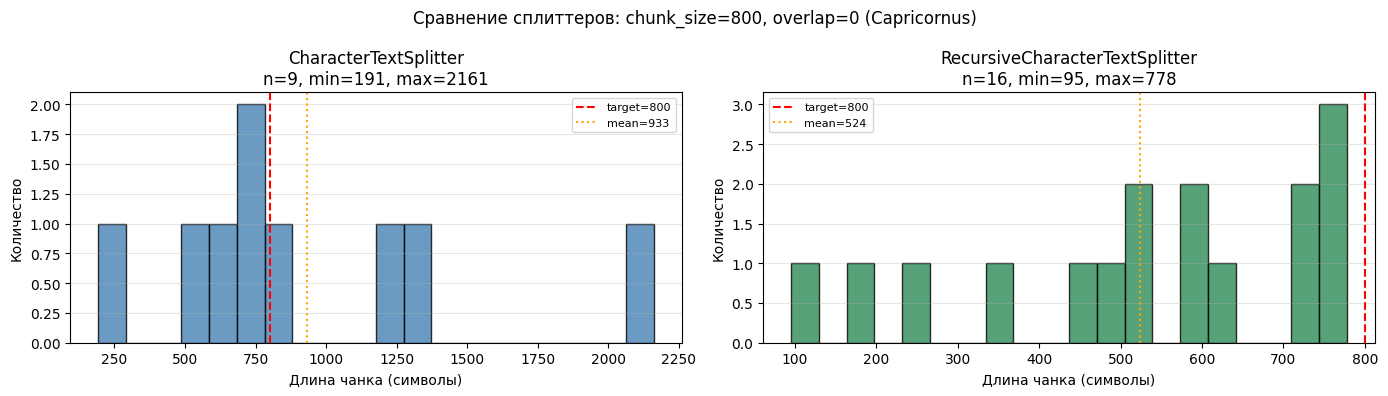

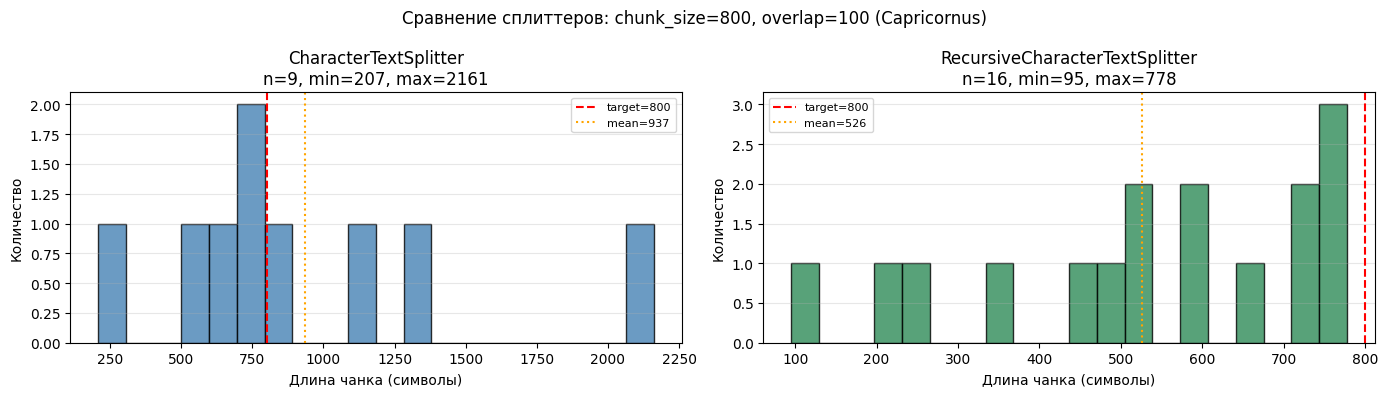

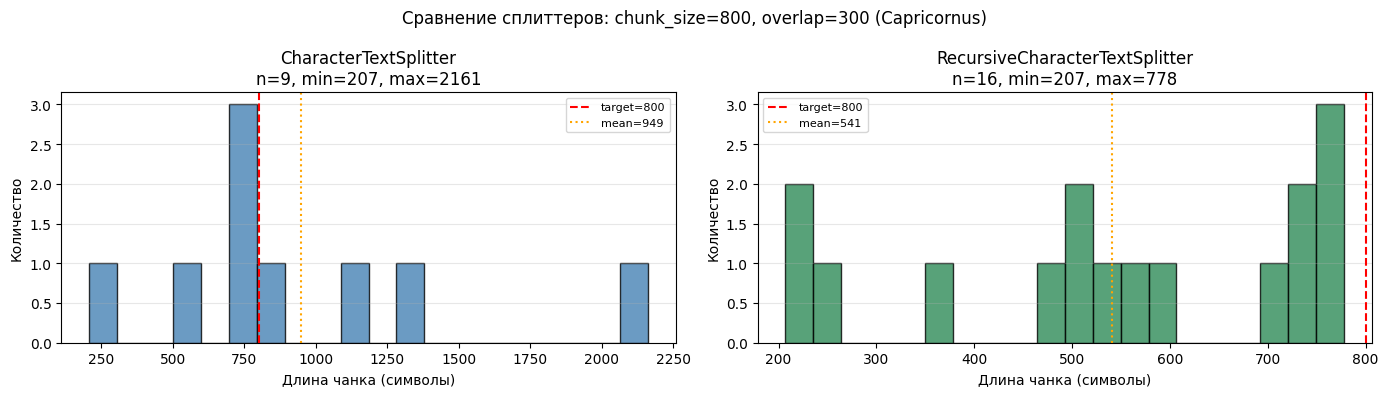

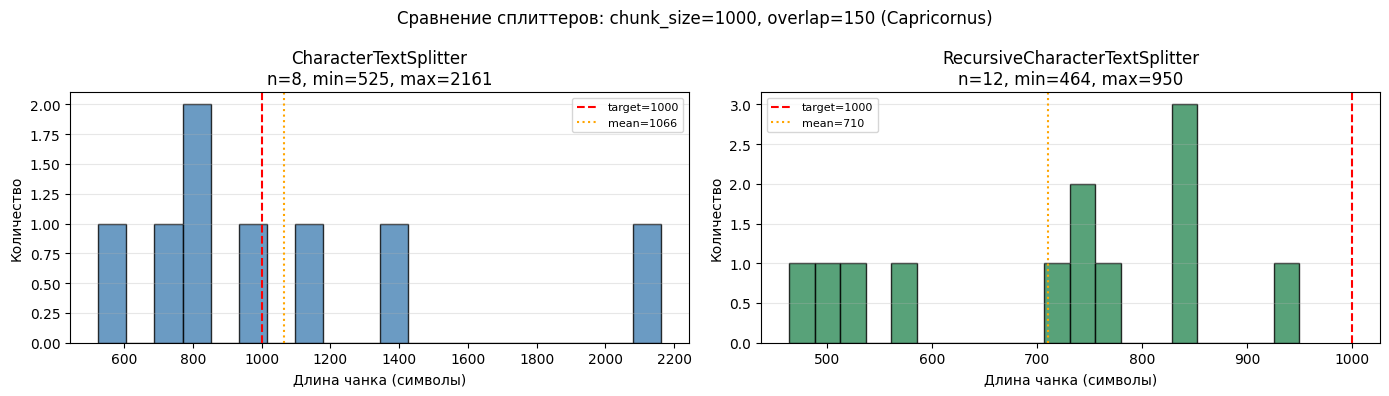

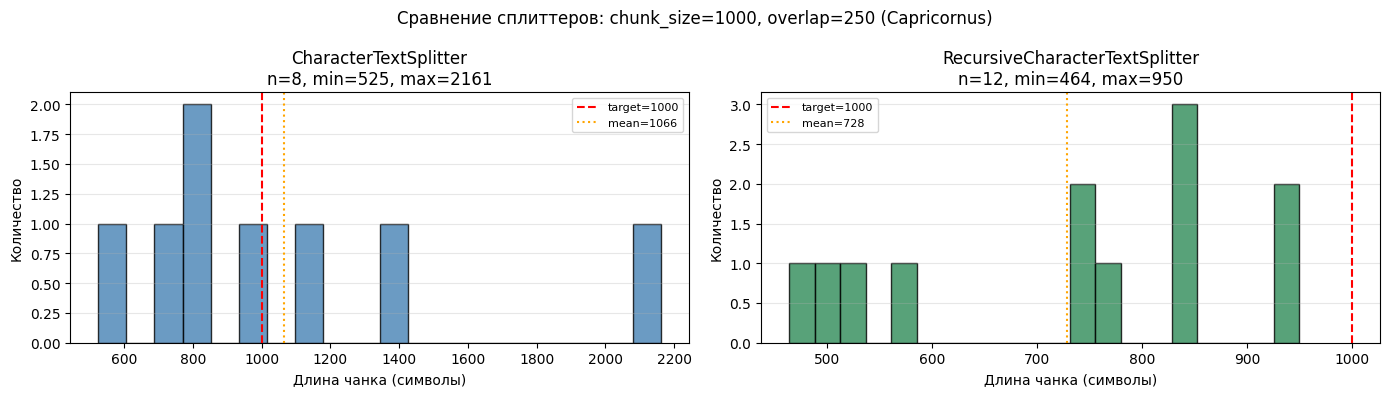

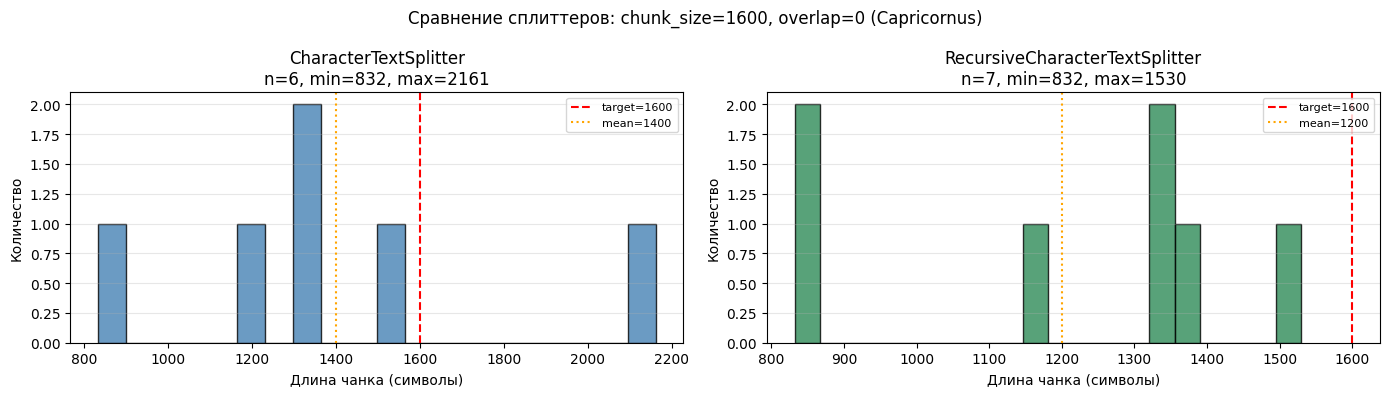

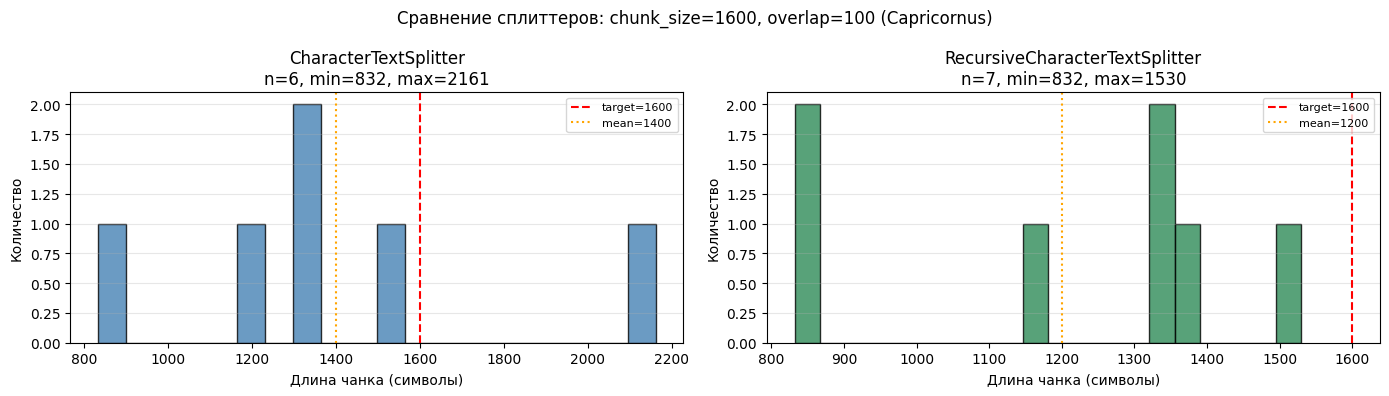

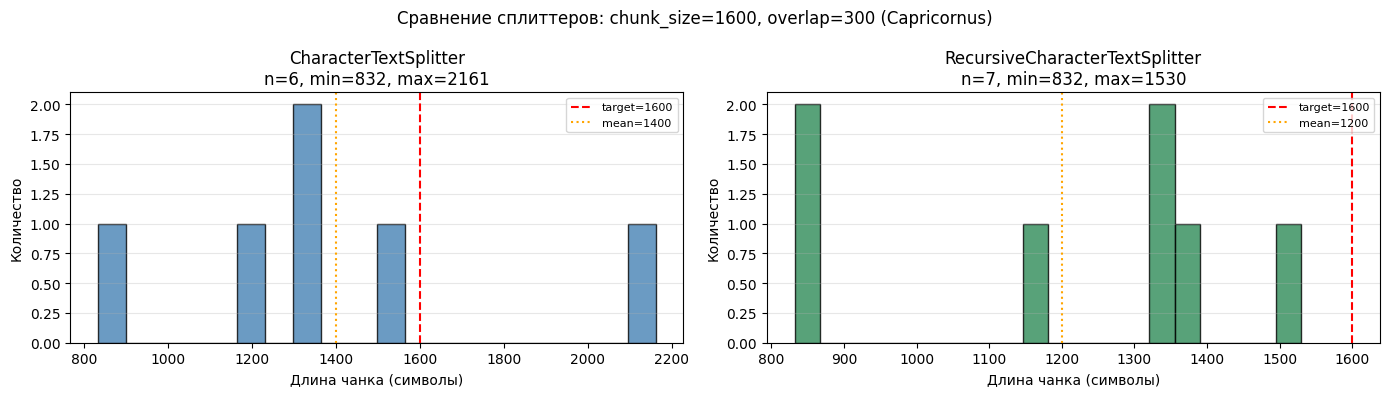

In [20]:
for params in params_to_test:
    plot_splitter_comparison(
        text=articles['Capricornus'],
        chunk_size=params["chunk_size"],
        chunk_overlap=params["chunk_overlap"],
        sample_name="Capricornus"
    )

In [ ]:
  plot_splitter_comparison(
        text=sample_text,
        chunk_size=100,
        chunk_overlap=overlap,
        sample_name="Orion (extreme small)"
    )

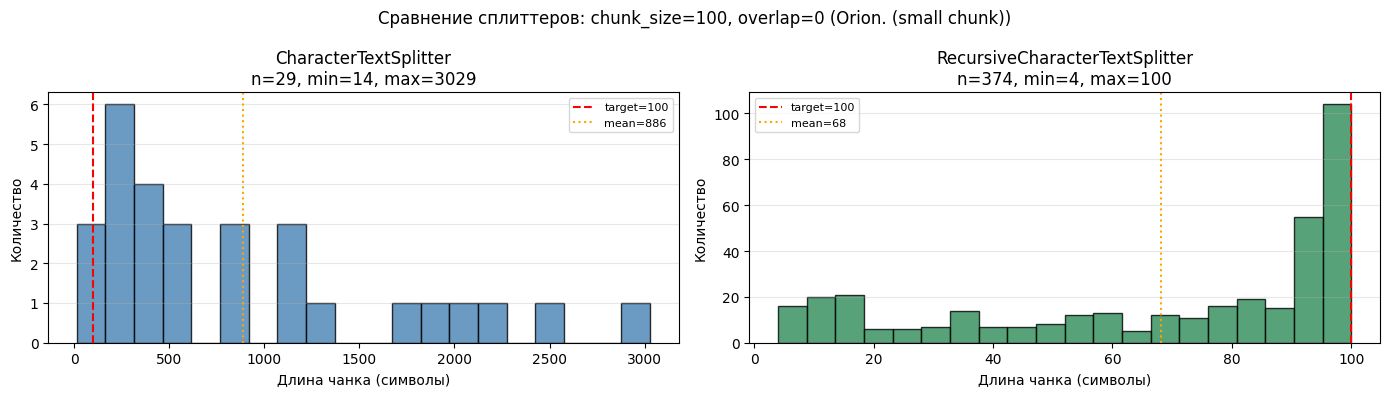

In [24]:
    plot_splitter_comparison(
        text=articles['Orion'],
        chunk_size=100,
        chunk_overlap=0,
        sample_name="Orion. (small chunk)"
    )

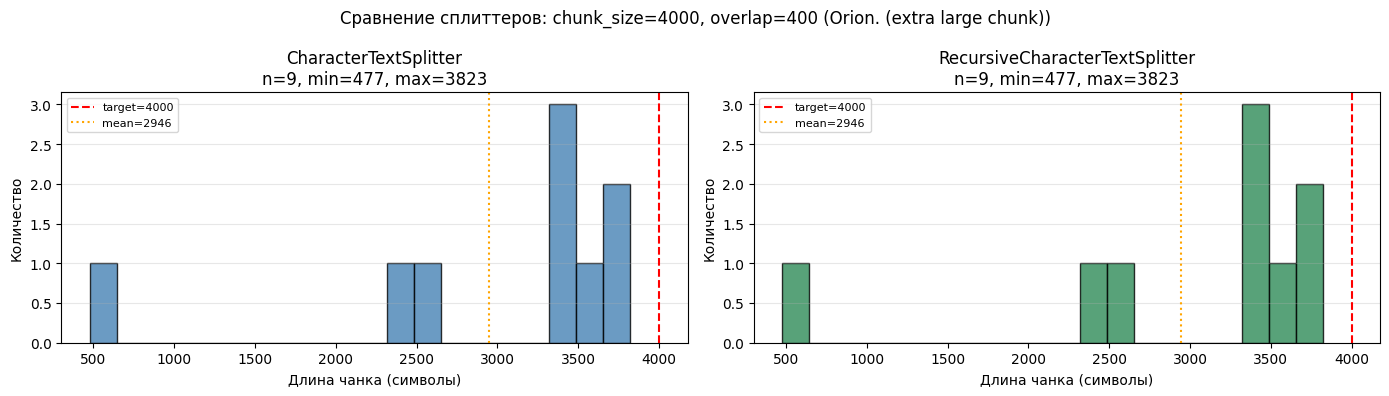

In [22]:
  plot_splitter_comparison(
        text=articles['Orion'],
        chunk_size=4000,
        chunk_overlap=400,
        sample_name="Orion. (extra large chunk)"
    )

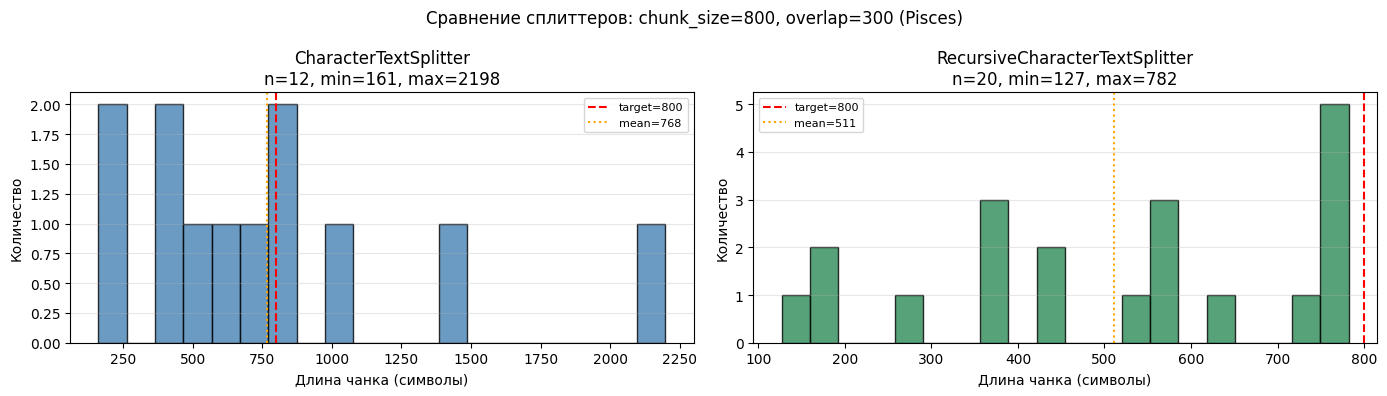

In [31]:
 plot_splitter_comparison(
        text=articles['Pisces'],
        chunk_size=800,
        chunk_overlap=300,
        sample_name="Pisces"
    )

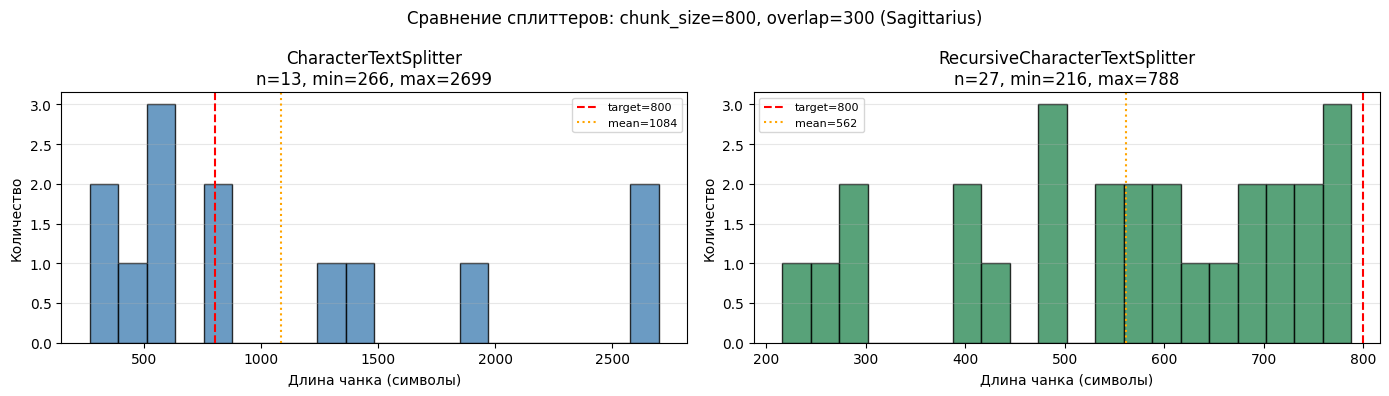

In [30]:

  plot_splitter_comparison(
        text=articles['Sagittarius'],
        chunk_size=800,
        chunk_overlap=300,
        sample_name="Sagittarius"
    )

In [26]:
len(articles['Orion'])

25753

In [25]:
len(articles['Capricornus'])

8410

In [32]:
import numpy as np
from scipy import stats

def evaluate_chunk_distribution(chunks: List[str], target_size: int) -> Dict[str, float]:
    """
    Считает метрики для оценки качества распределения длин чанков.
    """
    lengths = np.array([len(c) for c in chunks])
    n = len(lengths)

    in_range = np.sum((lengths >= 0.9 * target_size) & (lengths <= 1.1 * target_size))
    pct_in_range = 100 * in_range / n

    cv = np.std(lengths) / np.mean(lengths)

    skew = stats.skew(lengths)

    mean_error_pct = 100 * (np.mean(lengths) - target_size) / target_size

    outliers = np.sum((lengths < 0.5 * target_size) | (lengths > 1.5 * target_size))
    pct_outliers = 100 * outliers / n

    q1, q3 = np.percentile(lengths, [25, 75])
    iqr_pct = 100 * (q3 - q1) / target_size

    return {
        'n_chunks': n,
        'pct_in_10pct_range': round(pct_in_range, 1),
        'coefficient_of_variation': round(cv, 3),
        'skewness': round(skew, 3),
        'mean_error_pct': round(mean_error_pct, 1),
        'pct_outliers': round(pct_outliers, 1),
        'iqr_pct_of_target': round(iqr_pct, 1),
    }

In [ ]:
CharacterTextSplitter

In [35]:
configs = [
    {"chunk_size": 400, "chunk_overlap": 0},
    {"chunk_size": 400, "chunk_overlap": 100},
    {"chunk_size": 400, "chunk_overlap": 300},
    {"chunk_size": 800, "chunk_overlap": 0},
    {"chunk_size": 800, "chunk_overlap": 100},
    {"chunk_size": 800, "chunk_overlap": 300},
    {"chunk_size": 1000, "chunk_overlap": 150},
    {"chunk_size": 1000, "chunk_overlap": 250},
    {"chunk_size": 1600, "chunk_overlap": 0},
    {"chunk_size": 1600, "chunk_overlap": 100},
    {"chunk_size": 1600, "chunk_overlap": 300},
]

results = []

for cfg in configs:
    splitter = CharacterTextSplitter(
        chunk_size=cfg["chunk_size"],
        chunk_overlap=cfg["chunk_overlap"],
        length_function=len,
    )
    chunks = splitter.split_text(sample_text)
    metrics = evaluate_chunk_distribution(chunks, cfg["chunk_size"])
    metrics['config'] = f"size={cfg['chunk_size']}, overlap={cfg['chunk_overlap']}"
    results.append(metrics)
    print(f"{metrics['config']}: {metrics}")

import pandas as pd
df = pd.DataFrame(results)
print("\nСводная таблица метрик:")
print(df[['config', 'pct_in_10pct_range', 'coefficient_of_variation', 'pct_outliers']].to_string(index=False))

size=400, overlap=0: {'n_chunks': 27, 'pct_in_10pct_range': np.float64(14.8), 'coefficient_of_variation': np.float64(0.83), 'skewness': np.float64(1.062), 'mean_error_pct': np.float64(138.0), 'pct_outliers': np.float64(59.3), 'iqr_pct_of_target': np.float64(221.0), 'config': 'size=400, overlap=0'}
size=400, overlap=100: {'n_chunks': 27, 'pct_in_10pct_range': np.float64(14.8), 'coefficient_of_variation': np.float64(0.83), 'skewness': np.float64(1.062), 'mean_error_pct': np.float64(138.0), 'pct_outliers': np.float64(59.3), 'iqr_pct_of_target': np.float64(221.0), 'config': 'size=400, overlap=100'}
size=400, overlap=300: {'n_chunks': 27, 'pct_in_10pct_range': np.float64(14.8), 'coefficient_of_variation': np.float64(0.83), 'skewness': np.float64(1.062), 'mean_error_pct': np.float64(138.0), 'pct_outliers': np.float64(59.3), 'iqr_pct_of_target': np.float64(221.0), 'config': 'size=400, overlap=300'}
size=800, overlap=0: {'n_chunks': 23, 'pct_in_10pct_range': np.float64(17.4), 'coefficient_of_v

In [34]:
configs = [
    {"chunk_size": 400, "chunk_overlap": 0},
    {"chunk_size": 400, "chunk_overlap": 100},
    {"chunk_size": 400, "chunk_overlap": 300},
    {"chunk_size": 800, "chunk_overlap": 0},
    {"chunk_size": 800, "chunk_overlap": 100},
    {"chunk_size": 800, "chunk_overlap": 300},
    {"chunk_size": 1000, "chunk_overlap": 150},
    {"chunk_size": 1000, "chunk_overlap": 250},
    {"chunk_size": 1600, "chunk_overlap": 0},
    {"chunk_size": 1600, "chunk_overlap": 100},
    {"chunk_size": 1600, "chunk_overlap": 300},
]

results = []

for cfg in configs:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=cfg["chunk_size"],
        chunk_overlap=cfg["chunk_overlap"],
        length_function=len,
    )
    chunks = splitter.split_text(sample_text)
    metrics = evaluate_chunk_distribution(chunks, cfg["chunk_size"])
    metrics['config'] = f"size={cfg['chunk_size']}, overlap={cfg['chunk_overlap']}"
    results.append(metrics)
    print(f"{metrics['config']}: {metrics}")

import pandas as pd
df = pd.DataFrame(results)
print("\nСводная таблица метрик:")
print(df[['config', 'pct_in_10pct_range', 'coefficient_of_variation', 'pct_outliers']].to_string(index=False))

size=400, overlap=0: {'n_chunks': 105, 'pct_in_10pct_range': np.float64(34.3), 'coefficient_of_variation': np.float64(0.575), 'skewness': np.float64(-0.349), 'mean_error_pct': np.float64(-39.0), 'pct_outliers': np.float64(38.1), 'iqr_pct_of_target': np.float64(65.8), 'config': 'size=400, overlap=0'}
size=400, overlap=100: {'n_chunks': 107, 'pct_in_10pct_range': np.float64(35.5), 'coefficient_of_variation': np.float64(0.48), 'skewness': np.float64(-0.72), 'mean_error_pct': np.float64(-32.8), 'pct_outliers': np.float64(28.0), 'iqr_pct_of_target': np.float64(55.0), 'config': 'size=400, overlap=100'}
size=400, overlap=300: {'n_chunks': 147, 'pct_in_10pct_range': np.float64(59.9), 'coefficient_of_variation': np.float64(0.354), 'skewness': np.float64(-1.761), 'mean_error_pct': np.float64(-18.8), 'pct_outliers': np.float64(13.6), 'iqr_pct_of_target': np.float64(21.2), 'config': 'size=400, overlap=300'}
size=800, overlap=0: {'n_chunks': 51, 'pct_in_10pct_range': np.float64(25.5), 'coefficient_

**Ваш ответ:**
1) Какой сплиттер вы бы выбрали для дальнейшей работы и почему?

Я выбираю RecursiveCharacterTextSplitter. Он использует иерархию разделителей (\n\n → \n → . →  → символы), что позволяет разбивать текст по более естественным смысловым границам. Этим методом получается больше чанков для теста и они  ближе к целевом у размеру, тогда как  при помощи CharacterTextSplitter часто есть получаются выбросы в сторону большей длины чанков относительно целевой.

2) При каких chunk_size и chunk_overlap распределение выглядит самым ровным?
Конфигурация chunk_size = 400 chunk_overlap = 300 даёт наибольшую долю чанков, близких к target, потому что большое перекрытие «сглаживает» границы и позволяет сплиттеру чаще попадать в целевой диапазон.

Конфигурации с chunk_size=1600 имеют наименьший разброс (CV) и минимум выбросов, так как крупные смысловые блоки реже дробятся экстремально.

**Итоговая кофигурация: RecursiveCharacterTextSplitter chunk_size = 800 и chunk_overlap = 300 **

Хотя отмеченные ранее конфигурации более "ровные", конфигурация с параметрами chunk_size = 800 и chunk_overlap = 300 или 100 (результаты близки друг другу) является более практически применимой. Так как пик гистограммы соответствует/близок целевому значению. Мало прям критических значений. Средний размер чанков близок к целевому. Этот размер чанков будет более близок к компромисному.


3) Что произойдёт с retrieval, если поставить `chunk_size=100`? А `chunk_size=4000`?

При `chunk_size=100`
Чанки могут становятся слишком короткими, чтобы содержать законченную мысль или полный ответ на вопрос. Векторы становятся менее информативными.  Похожие короткие фрагменты из разных статей могут иметь близкие эмбеддинги. За счет большего количества чанков поиск будет дольше.

При `chunk_size=4000`
Релевантная информация будет «размывается» в большом объёме нерелевантного текста, модели сложнее выделить точный ответ. Также Повышается вероятность, что в один чанк попадут противоречащие друг другу факты из разных разделов статьи, что может спровоцировать галлюцинации или некорректные обобщения. Большой размер чанка может не влезть в контекстное окно одной модели.

В обоих случаях сложнее найти всю необходимую информацию для ответа и определить какая реально релевантна.

## 1.3. Чанкование всех статей с метаданными

Идём дальше с `RecursiveCharacterTextSplitter` (для всех статей). К каждому чанку привязываем метаданные:
- `constellation` — название созвездия, чтобы можно было фильтровать или цитировать источник;
- `chunk_id` — порядковый номер чанка внутри статьи;
- `source` — точное название Wikipedia-страницы.

In [4]:
from langchain_core.documents import Document

# Собираем все чанки со всех статей в один список документов
all_documents: List[Document] = []

# Создаём пустой список, в который будем складывать все документы-чанки
all_documents = []

CHUNK_SIZE = 800
CHUNK_OVERLAP = 300

recursive_splitter = RecursiveCharacterTextSplitter(
    separators=['\n\n', '\n', '. ', ' ', ''],  # от смысловых границ к посимвольным
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len,
)

# Проходим по каждой статье: берём название созвездия и полный текст статьи
for constellation_name, text in articles.items():

    # Разбиваем полный текст статьи на небольшие фрагменты с помощью чанкера, который вы выбрали (тут recursive)
    chunks = recursive_splitter.split_text(text)
    # Проходим по всем чанкам текущей статьи
    # idx — номер чанка внутри статьи
    # chunk — текст конкретного чанка
    for idx, chunk in enumerate(chunks):

        # Создаём объект Document для одного чанка
        # page_content хранит сам текст чанка
        # metadata хранит дополнительную информацию о происхождении чанка
        NO_SUFFIX = {"Scorpius", "Lyra", "Centaurus", "Crux", "Capricornus"}
        original_title = constellation_name if constellation_name in NO_SUFFIX else f"{constellation_name} (constellation)"

        doc = Document(
            page_content=chunk,
            metadata={
                # Название созвездия, к которому относится этот чанк
                'constellation': constellation_name,
                # Номер чанка внутри исходной статьи
                'chunk_id': idx,
                # Точное название страницы Wikipedia, откуда была взята статья (заменила на очищенное имя)
                'source': original_title,
            }
        )

        # Добавляем созданный документ в общий список
        all_documents.append(doc)
print(f'Всего чанков: {len(all_documents)}')
# Проверяем, что всё работает
print('\nПример первого чанка:')
print('Metadata:', all_documents[0].metadata)
print('Content[:300]:', all_documents[0].page_content[:300])

Всего чанков: 733

Пример первого чанка:
Metadata: {'constellation': 'Orion', 'chunk_id': 0, 'source': 'Orion (constellation)'}
Content[:300]: Orion is a prominent set of stars visible during winter in the northern celestial hemisphere. It is one of the 88 modern constellations; it was among the 48 constellations listed by the 2nd-century AD astronomer Ptolemy. It is named after a hunter in Greek mythology.


## 1.4. Эмбеддинги и векторное хранилище ChromaDB


In [6]:
!pip install chromadb

In [5]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
import torch
import chromadb

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Эмбеддинги будут считаться на: {device}')

client = chromadb.Client()

try:
    client.delete_collection("constellations")
    print("Старая коллекция 'constellations' удалена.")
except Exception:
    print("Коллекция не найдена (запуск в чистом окружении).")

# Загружаем модель эмбеддингов
embeddings = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2',
    model_kwargs={'device': device},
    encode_kwargs={
        'normalize_embeddings': True,
        'batch_size': 128
    },
)

# Создаём векторное хранилище и индексируем все наши документы
# Под капотом каждый chunk прогоняется через embeddings и кладётся в Chroma
vectorstore = Chroma.from_documents(
    documents=all_documents,  # список документов из предыдущей ячейки
    embedding=embeddings,  # наша модель эмбеддингов
    collection_name='constellations',  # имя коллекции внутри Chroma
)

print(f'Проиндексировано: {vectorstore._collection.count()} чанков')

Эмбеддинги будут считаться на: cuda
Коллекция не найдена (запуск в чистом окружении).


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Проиндексировано: 733 чанков


In [27]:
# Ищем 3 ближайших чанка к простому запросу
test_query = 'What is the brightest star in Orion?'
results = vectorstore.similarity_search(test_query, k=3)
for i, doc in enumerate(results):
    # Смотрим, что нашлось что-то разумное
    print(f'--- Результат #{i+1} (constellation={doc.metadata["constellation"]}, chunk_id={doc.metadata["chunk_id"]}) ---')
    print(doc.page_content[:300])
    print()

--- Результат #1 (constellation=Orion, chunk_id=8) ---
Bright stars
Betelgeuse, also designated Alpha Orionis, is a massive M-type red supergiant star nearing the end of its life. It is the second-brightest star in Orion, and is a semiregular variable star. It serves as the right shoulder of the hunter (assuming that he is facing the observer). It is ge

--- Результат #2 (constellation=Orion, chunk_id=1) ---
Orion is most prominent during winter evenings in the Northern Hemisphere, as are five other constellations that have stars in the Winter Hexagon asterism. Orion's two brightest stars, Rigel (β) and Betelgeuse (α), are both among the brightest stars in the night sky; both are supergiants and slightl

--- Результат #3 (constellation=Orion, chunk_id=15) ---
Orion's Belt, or The Belt of Orion, is an asterism within the constellation. It consists of three bright stars: Alnitak (Zeta Orionis), Alnilam (Epsilon Orionis), and Mintaka (Delta Orionis). Alnitak is around 800 light-years away

Результат хороший, но лучший ответ содержит чанк 2. Ни один чанк не содержит фразу "Rigel is the brightest star in Orion" - модели придётся делать логический вывод на основе контекста.

## 1.5. LLM для генерации ответов: Qwen (1,5 балла)

Берём `Qwen/Qwen2.5-0.5B-Instruct`,  на CPU она работает медленно, но работает. Если у вас работает медленно, то используйте с явным `torch_dtype=torch.float32` и небольшим `max_new_tokens`.

Альтернативно можете подключить любую другую модель через HF pipeline.

Что необходимо сделать:

1.  Соберите pipeline для генерации текста с моделью Qwen, которую мы загрузили.[Тут можете посмотреть информацию о pipeline](https://huggingface.co/docs/transformers/main_classes/pipelines#transformers.TextGenerationPipeline)

выше (model, tokenizer) - 1 балл

Требования к параметрам:

*   Task - 'text-generation'
*   Уже загруженные model и tokenizer
*   Максимум новых токенов. Определите ограничение длины ответа модели. Чем меньше, тем быстрее на CPU, но можно обрезать ответ на середине.
*   Отключите сэмплирование (детерминированная генерация), чтобы при повторных запусках получать одинаковый ответ
*   Штраф за повторы: значения >1 наказывают модель за повторение уже сгенерированных токенов, что помогает бороться с зацикливаниями маленьких моделей
*   Только ответ модели в выводе: настройте так, чтобы pipeline возвращал только сгенерированный текст без эхо промпта

2. Пропишите промпты для system и user промпты - 0,5 балла



In [37]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

LLM_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'

tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)
model = AutoModelForCausalLM.from_pretrained(
    LLM_MODEL,
    torch_dtype=torch.float32,
    device_map='auto'
)


llm_pipeline = pipeline(
    'text-generation',
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=200,
    do_sample=False,
    repetition_penalty=1.2,
    return_full_text=False,
    pad_token_id=tokenizer.eos_token_id,
)


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [8]:
def generate_answer(question: str, context: str) -> str:
    """Собирает промпт из вопроса и контекста, прогоняет через Qwen и возвращает ответ."""
    # ДЛя модели нужен формат chat: [{'role': 'system', ...}, {'role': 'user', ...}]
    messages = [
        {
            'role': 'system',
            # System prompt задаёт роль и явно ограничивает модель только контекстом
            'content': (
    "You are a factual astronomical assistant. Your task is to answer questions "
    "using ONLY the retrieved context provided below. Follow these rules strictly:\n"
    "1. If the answer is not explicitly stated in the context, respond: "
    "'I do not have information about this in the provided sources.'\n"
    "2. Do not use external knowledge, common sense, or assumptions.\n"
    "3. Do not paraphrase numerical facts, coordinates, or proper names — quote them exactly.\n"
    "4. Keep answers concise (1–3 sentences) unless the question requires elaboration.\n"
    "5. If multiple context chunks contain relevant information, synthesize them without contradiction."
)
        },
        {
            'role': 'user',
            # Передаём контекст и вопрос в user-message — простой шаблон
            'content': f"Context:\n{context}\n\nQuestion: {question}"
        }
    ]
    # Применяем chat-template токенизатора — он сам подставит спецтокены Qwen
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,  #pipeline сам токенизирует
        add_generation_prompt=True,  # добавит токен начала ответа ассистента
    )
    # Прогоняем через pipeline
    output = llm_pipeline(prompt)
    # Берём текст ответа и убираем хвостовые пробелы
    return output[0]['generated_text'].strip()

# Быстрая проверка
print(generate_answer(
    question='What is Orion?',
    context='Orion is a prominent constellation located on the celestial equator and visible throughout the world.'
))

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Orion is a prominent constellation located on the celestial equator and visible throughout the world.


## 1.6. Полный pipeline (0,5 баллов)

Объединяем retrieval и генерацию в одну функцию. Возвращаем не только ответ, но и **источники**. Это важно для отладки и для того, чтобы видеть, опирался ли LLM на правильный контекст.

Допишите функцию rag_query, которая собирает весь RAG пайплайн

In [9]:
def rag_query(question: str, k: int = 4, verbose: bool = True) -> Dict:
    """Полный RAG-пайплайн: retrieval из Chroma → склейка контекста → генерация ответа."""
    # Шаг 1: получаем top-k наиболее похожих чанков по cosine similarity
    retrieved_docs = vectorstore.similarity_search(question, k=k)
    # Шаг 2: склеиваем все найденные чанки в единый контекст
    # Двойной перевод строки между чанками, чтобы модель видела границы
    context = "\n\n".join([doc.page_content for doc in retrieved_docs])
    # Шаг 3: вызываем LLM с собранным контекстом
    answer = generate_answer(question, context)
    # Шаг 4: собираем структурированный результат для удобной отладки
    result = {
        "question": question,
        "answer": answer,
        "sources": [
            {
                "constellation": doc.metadata["constellation"],
                "chunk_id": doc.metadata["chunk_id"],
                "preview": doc.page_content[:150] + "..."
            }
            for doc in retrieved_docs
        ]
    }
    # Функция распечатает вопрос, ответ и источники прямо в вывод ячейки, если verbose == True
    if verbose:
        print(f"Вопрос: {question}")
        print(f"Ответ: {answer}")
        print("\nИсточники:")
        for i, src in enumerate(result["sources"], 1):
            print(f"{i}. [{src['constellation']} (chunk {src['chunk_id']})] {src['preview']}")
        print("-" * 60)

    return result

## 1.7. Тестирование (1 балл)


1.   Придумайте 7 вопросов с разной сложностью и охватом, чтобы проверить, как справляется с ними RAG - 0,5 балла

Примеры:


*   Which constellations are part of the zodiac? -  требует знаний по всему корпусу
*   Compare Ursa Major and Scorpius in terms of visibility from the northern hemisphere. - сравнительный вопрос
*   How was Cassiopeia named in Greek mythology? - культурно-исторический контекст


2.   Проведите небольшие эксперименты и ответьте на вопросы - 0,5 балла


*   Что произойдёт, если поменять k=4 на k=1 и на k=10? Когда больше контекста, становится хуже?
*   На каких типах запросов RAG работает лучше: на локальных (один факт) или на агрегирующих (нужна информация из нескольких статей)? Почему?
*   Как справляется RAG с вопросами про созвездия, которых нет в базе данных?









In [43]:
story_queries = [
    # 1. Простой факт об одной звезде
    "What color is the star Betelgeuse?",
    # 2. Простой факт о видимости одного созвездия
    "In which hemisphere is the constellation Crux primarily visible?",
    # 3. Соседние созвездия
    "Which constellation is located between Hercules and Pegasus?",
    # 4. Эволюция звезды
    "What is the expected final evolutionary stage of Betelgeuse?",
    # 5. Сравнение звёзд по светимости
    "Compare the luminosity of Rigel and Betelgeuse based on the provided context.",
    # 6. Расстояние + сравнение
    "What is the distance to Vega in light-years, and how does it compare to the distance of Deneb?",
    # 7. Агрегация по мифологическому признаку
    "Which constellations in the dataset are named after mythological hunters?",
    # 7. Агрегация по мифологическому признаку
    "Which constellations in the dataset are named after mythological hunters?",
    # 8. Провека на галюциннации не про звезды вопрос
    "What is the orbital period of the exoplanet orbiting the star Fomalhaut in the constellation Piscis Austrinus?",
    # 9. Доп вопрос не про звезды должен отказаться отвечать
    "What color is the apple?",
]


results_manual = []
for q in story_queries:
    result = rag_query(q, k=4, verbose=True)
    results_manual.append(result)

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: What color is the star Betelgeuse?
Ответ: The star Betelgeuse is described as having a color of orange-hued giant star of type K3 orange giant of magnitude 3.3.

Источники:
1. [Orion (chunk 8)] Bright stars
Betelgeuse, also designated Alpha Orionis, is a massive M-type red supergiant star nearing the end of its life. It is the second-brightes...
2. [Orion (chunk 7)] Features
Orion's seven brightest stars form a distinctive hourglass-shaped asterism, or pattern, in the night sky. Four stars—Rigel, Betelgeuse, Bella...
3. [Lyra (chunk 29)] . The middle region is colored green; doubly ionized oxygen emits greenish-blue light. The hottest region, closest to the central star, appears blue b...
4. [Andromeda (chunk 20)] δ And is an orange-hued giant star of type K3 orange giant of magnitude 3.3. It is 105 light-years from Earth.
ι And (Rasalnaqa), κ (Kaffalmusalsala),...
------------------------------------------------------------


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: In which hemisphere is the constellation Crux primarily visible?
Ответ: The constellation Crux is primarily visible from the Southern Hemisphere.

Источники:
1. [Crux (chunk 20)] Visibility
Crux is easily visible from the Southern Hemisphere, south of 35th parallel at practically any time of year as circumpolar. It is also visi...
2. [Crux (chunk 21)] Due to precession, Crux will move closer to the South Pole in the next few millennia, up to 67° south declination for the middle of the constellation....
3. [Crux (chunk 18)] Characteristics
Crux is bordered by the constellations Centaurus (which surrounds it on three sides) on the east, north, and west, and Musca to the so...
4. [Crux (chunk 0)] Crux ( KRUKS) is a constellation of the southern sky that is centred on four bright stars in a cross-shaped asterism commonly known as the Southern Cr...
------------------------------------------------------------


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Вопрос: Which constellations in the dataset are named after mythological hunters?
Ответ: Aldebaran, which corresponds to Orion's arrow, is often depicted among those who hunt for arrows.

Источники:
1. [Hercules (chunk 29)] The constellation is connected with Hercules in De astronomia (probably 1st century BCE/CE, and attributed to Hyginus), which describes several differ...
2. [Pegasus (chunk 27)] External links

The Deep Photographic Guide to the Constellations: Pegasus
The clickable Pegasus
Star Tales – Pegasus
Warburg Institute Iconographic D...
3. [Orion (chunk 26)] History and mythology
The distinctive pattern of Orion is recognized in numerous cultures around the world, and many myths are associated with it. Ori...
4. [Ursa Major (chunk 0)] Ursa Major, also known as the Great Bear, is a constellation in the Northern Sky, whose associated mythology likely dates back into prehistory. Its La...
------------------------------------------------------------


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: Which constellations in the dataset are named after mythological hunters?
Ответ: Aldebaran, which corresponds to Orion's arrow, is often depicted among those who hunt for arrows.

Источники:
1. [Hercules (chunk 29)] The constellation is connected with Hercules in De astronomia (probably 1st century BCE/CE, and attributed to Hyginus), which describes several differ...
2. [Pegasus (chunk 27)] External links

The Deep Photographic Guide to the Constellations: Pegasus
The clickable Pegasus
Star Tales – Pegasus
Warburg Institute Iconographic D...
3. [Orion (chunk 26)] History and mythology
The distinctive pattern of Orion is recognized in numerous cultures around the world, and many myths are associated with it. Ori...
4. [Ursa Major (chunk 0)] Ursa Major, also known as the Great Bear, is a constellation in the Northern Sky, whose associated mythology likely dates back into prehistory. Its La...
------------------------------------------------------------


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: What is the orbital period of the exoplanet orbiting the star Fomalhaut in the constellation Piscis Austrinus?
Ответ: The exoplanet orbiting the star Fomalhaut in the constellation Piscis Austrinus has an orbital period of 182 days.

Источники:
1. [Aquarius (chunk 19)] Planetary systems
Twelve exoplanet systems have been found in Aquarius as of 2013. Gliese 876, one of the nearest stars to Earth at a distance of 15 l...
2. [Pisces (chunk 0)] Pisces  is a constellation of the zodiac. Its vast bulk — and main asterism viewed in most European cultures per Greco-Roman antiquity as a distant pa...
3. [Aries (chunk 26)] The constellation is home to several double stars, including Epsilon, Lambda, and Pi Arietis. ε Arietis is a binary star with two white components. Th...
4. [Aries (chunk 27)] . λ Arietis is a wide double star with a white-hued primary and a yellow-hued secondary. The primary is of magnitude 4.8 and the secondary is of magni...
----------------------------------------

Из 9 тестовых запросов только 2 ответа были полностью корректны. При этом качество работы компонентов пайплайна различается:

Retrieval работает удовлетворительно.
В более чем половине случаев система находит релевантные чанки  - источники относятся к нужному созвездию и содержат полезную информацию

Генерация - слабое звено.

*  Однако, модель всегда выдаёт ответ в близком контексте. Ответы звучат уверенно и связно, даже когда фактически неверны

*   Часто встречается смешение фактов из разных чанков - модель комбинирует фрагменты без проверки, что одна и та же сущность упоминается в обоих источниках

Ожидаемые ограничения с которыми столкнылись из-за маленькой версии модели:
* С трудом справляется с агрегацией. Вопросы, требующие синтеза информации из нескольких статей (например, «какие созвездия названы в честь охотников?»), приводят к неполным или ошибочным ответам
* Не умеет говорить «не знаю».
* Допускает ошибки в доменных рассуждениях.




Проведем следующие улучшения и уже на них посмотрим эксперименты по работе.

1.   Улучшим системный промпт. Добавим явные инструкции не комбинировать факты из разных сущностей, требовать ответа «не знаю» при отсутствии данных в контексте и не использовать внешние знания.
2.  Сократим max_new_tokens до 150, так ка короткие ответы реже содержат галлюцинации и лучше укладываются в контекстное окно маленькой модели.
1.  Заменим модель на Qwen2.5-3B-Instruct







In [7]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# 3. Замена модели
LLM_MODEL = 'Qwen/Qwen2.5-3B-Instruct'

tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)

model = AutoModelForCausalLM.from_pretrained(
    LLM_MODEL,
    torch_dtype=torch.float16,
    device_map='auto',
    low_cpu_mem_usage=True,
)

llm_pipeline = pipeline(
    'text-generation',
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=150,
    do_sample=False,
    repetition_penalty=1.2,
    return_full_text=False,
    pad_token_id=tokenizer.eos_token_id,
)

print(f"Модель загружена на: {next(model.parameters()).device}")

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'repetition_penalty', 'pad_token_id', 'max_new_tokens', 'max_length', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Модель загружена на: cuda:0


In [10]:
def generate_answer(question: str, context: str) -> str:
    """Собирает промпт из вопроса и контекста, прогоняет через Qwen и возвращает ответ."""
    messages = [
        {
            'role': 'system',
            'content': (
                "You are a precise astronomical assistant. Answer using ONLY the provided context. "
                "STRICT RULES:\n"
                "1. If the answer is not explicitly stated in the context, respond exactly: "
                "'I do not have information about this in the provided sources.'\n"
                "2. Do NOT combine facts from different entities or chunks unless they explicitly refer to the same object.\n"
                "3. Do NOT use external knowledge, mythology, or astronomical data not present in the context.\n"
                "4. Keep the answer concise and factual."
            )
        },
        {
            'role': 'user',
            'content': f"Context:\n{context}\n\nQuestion: {question}"
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    output = llm_pipeline(prompt)
    return output[0]['generated_text'].strip()

# Быстрая проверка
print(generate_answer(
    question='What is the distance to Vega?',
    context='Vega is a main-sequence star of spectral type A0Va. Only 7.7 parsecs distant.'
))

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The distance to Vega is 7.7 parsecs.


In [11]:
story_queries = [
    # 1. Простой факт об одной звезде
    "What color is the star Betelgeuse?",
    # 2. Простой факт о видимости одного созвездия
    "In which hemisphere is the constellation Crux primarily visible?",
    # 3. Соседние созвездия
    "Which constellation is located between Hercules and Pegasus?",
    # 4. Эволюция звезды
    "What is the expected final evolutionary stage of Betelgeuse?",
    # 5. Сравнение звёзд по светимости
    "Compare the luminosity of Rigel and Betelgeuse based on the provided context.",
    # 6. Расстояние + сравнение
    "What is the distance to Vega in light-years, and how does it compare to the distance of Deneb?",
    # 7. Агрегация по мифологическому признаку
    "Which constellations in the dataset are named after mythological hunters?",
    # 8. Провека на галюциннации не про звезды вопрос
    "What is the orbital period of the exoplanet orbiting the star Fomalhaut in the constellation Piscis Austrinus?",
    # 9. Доп вопрос не про звезды должен отказаться отвечать
    "What color is the apple?",
]


results_manual = []
for q in story_queries:
    result = rag_query(q, k=4, verbose=True)
    results_manual.append(result)

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: What color is the star Betelgeuse?
Ответ: Red

Источники:
1. [Orion (chunk 8)] Bright stars
Betelgeuse, also designated Alpha Orionis, is a massive M-type red supergiant star nearing the end of its life. It is the second-brightes...
2. [Orion (chunk 7)] Features
Orion's seven brightest stars form a distinctive hourglass-shaped asterism, or pattern, in the night sky. Four stars—Rigel, Betelgeuse, Bella...
3. [Lyra (chunk 29)] . The middle region is colored green; doubly ionized oxygen emits greenish-blue light. The hottest region, closest to the central star, appears blue b...
4. [Andromeda (chunk 20)] δ And is an orange-hued giant star of type K3 orange giant of magnitude 3.3. It is 105 light-years from Earth.
ι And (Rasalnaqa), κ (Kaffalmusalsala),...
------------------------------------------------------------


Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: In which hemisphere is the constellation Crux primarily visible?
Ответ: The constellation Crux is primarily visible in the Southern Hemisphere.

Источники:
1. [Crux (chunk 20)] Visibility
Crux is easily visible from the Southern Hemisphere, south of 35th parallel at practically any time of year as circumpolar. It is also visi...
2. [Crux (chunk 21)] Due to precession, Crux will move closer to the South Pole in the next few millennia, up to 67° south declination for the middle of the constellation....
3. [Crux (chunk 18)] Characteristics
Crux is bordered by the constellations Centaurus (which surrounds it on three sides) on the east, north, and west, and Musca to the so...
4. [Crux (chunk 0)] Crux ( KRUKS) is a constellation of the southern sky that is centred on four bright stars in a cross-shaped asterism commonly known as the Southern Cr...
------------------------------------------------------------


Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Вопрос: What is the distance to Vega in light-years, and how does it compare to the distance of Deneb?
Ответ: Vega is approximately 25 light-years away from Earth. The context does not provide the exact distance to Deneb, so I do not have information about its comparison relative to Vega.

Источники:
1. [Lyra (chunk 11)] The brightest star in the constellation is Vega (Alpha Lyrae), a main-sequence star of spectral type A0Va. Only 7.7 parsecs distant, Vega is a Delta S...
2. [Lyra (chunk 12)] Vega is one of the most magnificent of all stars, and has been called "arguably the next most important star in the sky after the Sun". Vega was the f...
3. [Cassiopeia (chunk 25)] . Rho Cassiopeiae is about 10,000 light-years from Earth.  Cassiopeia includes V509 Cassiopeiae, a second example of the extremely rare yellow hypergi...
4. [Cassiopeia (chunk 17)] Delta Cassiopeiae, also known as Ruchbah or Rukbat, meaning "knee," is a possible Algol-type eclipsing binary star with a maximum brightness

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: Which constellations in the dataset are named after mythological hunters?
Ответ: Pegasus

Источники:
1. [Hercules (chunk 29)] The constellation is connected with Hercules in De astronomia (probably 1st century BCE/CE, and attributed to Hyginus), which describes several differ...
2. [Pegasus (chunk 27)] External links

The Deep Photographic Guide to the Constellations: Pegasus
The clickable Pegasus
Star Tales – Pegasus
Warburg Institute Iconographic D...
3. [Orion (chunk 26)] History and mythology
The distinctive pattern of Orion is recognized in numerous cultures around the world, and many myths are associated with it. Ori...
4. [Ursa Major (chunk 0)] Ursa Major, also known as the Great Bear, is a constellation in the Northern Sky, whose associated mythology likely dates back into prehistory. Its La...
------------------------------------------------------------


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: What is the orbital period of the exoplanet orbiting the star Fomalhaut in the constellation Piscis Austrinus?
Ответ: I do not have information about this in the provided sources.

Источники:
1. [Aquarius (chunk 19)] Planetary systems
Twelve exoplanet systems have been found in Aquarius as of 2013. Gliese 876, one of the nearest stars to Earth at a distance of 15 l...
2. [Pisces (chunk 0)] Pisces  is a constellation of the zodiac. Its vast bulk — and main asterism viewed in most European cultures per Greco-Roman antiquity as a distant pa...
3. [Aries (chunk 26)] The constellation is home to several double stars, including Epsilon, Lambda, and Pi Arietis. ε Arietis is a binary star with two white components. Th...
4. [Aries (chunk 27)] . λ Arietis is a wide double star with a white-hued primary and a yellow-hued secondary. The primary is of magnitude 4.8 and the secondary is of magni...
------------------------------------------------------------
Вопрос: What color is the apple?

In [13]:
local_queries = [

    "How many stars form Orion's Belt?",
    "What is the Bayer designation of the star Antares?"
]
results_manual = []
for q in local_queries:
    result = rag_query(q, k=4, verbose=True)
    results_manual.append(result)

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: How many stars form Orion's Belt?
Ответ: Three

Источники:
1. [Orion (chunk 7)] Features
Orion's seven brightest stars form a distinctive hourglass-shaped asterism, or pattern, in the night sky. Four stars—Rigel, Betelgeuse, Bella...
2. [Orion (chunk 15)] Orion's Belt, or The Belt of Orion, is an asterism within the constellation. It consists of three bright stars: Alnitak (Zeta Orionis), Alnilam (Epsil...
3. [Orion (chunk 18)] Sword
Orion's Sword contains the Orion Nebula, the Messier 43 nebula, Sh 2-279 (also known as the Running Man Nebula), and the stars Theta Orionis, Io...
4. [Orion (chunk 11)] Mintaka is designated Delta Orionis, despite being the faintest of the three stars in Orion's Belt. Its name means "the belt". It is a multiple star s...
------------------------------------------------------------
Вопрос: What is the Bayer designation of the star Antares?
Ответ: I do not have information about this in the provided sources.

Источники:
1. [Cygnus (chunk 10)] Stars


In [14]:
aggregating_queries = [

    "Which constellations in the dataset are part of the zodiac?",
    "Which constellations in the dataset contain stars that are part of the Winter Hexagon asterism?",
    "Which constellation has the largest area: Leo, Virgo, or Hercules?"
]
results_manual = []
for q in aggregating_queries:
    result = rag_query(q, k=4, verbose=True)
    results_manual.append(result)

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: Which constellations in the dataset are part of the zodiac?
Ответ: Cancer, Gemini, Aquarius

Источники:
1. [Cancer (chunk 3)] Features
Stars
Cancer is the dimmest of the zodiacal constellations, having only two stars above the fourth magnitude. The German cartographer Johann ...
2. [Gemini (chunk 0)] Gemini is one of the constellations of the zodiac and is located in the northern celestial hemisphere.  It was one of the 48 constellations described ...
3. [Cancer (chunk 23)] Astrology
As of 2002, the Sun appears in the constellation Cancer from July 20 to August 9. In tropical astrology, the Sun is considered to be in the ...
4. [Aquarius (chunk 0)] Aquarius is an equatorial constellation of the zodiac, between Capricornus and Pisces. Its name is Latin for "water-carrier" or "cup-carrier", and its...
------------------------------------------------------------


Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: Which constellations in the dataset contain stars that are part of the Winter Hexagon asterism?
Ответ: Orion

Источники:
1. [Orion (chunk 1)] Orion is most prominent during winter evenings in the Northern Hemisphere, as are five other constellations that have stars in the Winter Hexagon aste...
2. [Orion (chunk 6)] In countries close to the equator (e.g. Kenya, Indonesia, Colombia, Ecuador), Orion appears overhead in December around midnight and in the February e...
3. [Orion (chunk 0)] Orion is a prominent set of stars visible during winter in the northern celestial hemisphere. It is one of the 88 modern constellations; it was among ...
4. [Cassiopeia (chunk 13)] 'W' asterism
The five brightest stars of Cassiopeia – Alpha, Beta, Gamma, Delta, and Epsilon Cassiopeiae – form the characteristic W-shaped asterism. ...
------------------------------------------------------------
Вопрос: Which constellation has the largest area: Leo, Virgo, or Hercules?
Ответ: Hercules

Источники:
1

In [16]:
edge_queries = [
    # 1. Вопрос про созвездие, которого НЕТ в базе — модель должна ответить «не знаю»
    "What is the brightest star in the constellation Phoenix?",
    # 2. Вопрос вне домена - проверка, что система не отвечает на нерелевантные запросы
    "What is the capital of France?"
]
results_manual = []
for q in edge_queries:
    result = rag_query(q, k=4, verbose=True)
    results_manual.append(result)

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: What is the brightest star in the constellation Phoenix?
Ответ: I do not have information about this in the provided sources.

Источники:
1. [Aries (chunk 21)] Bright stars
Aries has three prominent stars forming an asterism, designated Alpha, Beta, and Gamma Arietis by Johann Bayer. Alpha (Hamal) and Beta (S...
2. [Orion (chunk 8)] Bright stars
Betelgeuse, also designated Alpha Orionis, is a massive M-type red supergiant star nearing the end of its life. It is the second-brightes...
3. [Aries (chunk 28)] Most of the other stars in Aries visible to the naked eye have magnitudes between 3 and 5. δ Ari, called Boteïn, is a star of magnitude 4.35, 170 ligh...
4. [Leo (chunk 2)] Leo is also home to a bright variable star, the red giant R Leonis. It is a Mira variable with a minimum magnitude of 10 and normal maximum magnitude ...
------------------------------------------------------------
Вопрос: What is the capital of France?
Ответ: I do not have information about this in the pro

In [17]:
story_queries = [
    # 1. Простой факт об одной звезде
    "What color is the star Betelgeuse?",
    # 2. Простой факт о видимости одного созвездия
    "In which hemisphere is the constellation Crux primarily visible?",
    # 3. Соседние созвездия
    "Which constellation is located between Hercules and Pegasus?",
    # 4. Эволюция звезды
    "What is the expected final evolutionary stage of Betelgeuse?",
    # 5. Сравнение звёзд по светимости
    "Compare the luminosity of Rigel and Betelgeuse based on the provided context.",
    # 6. Расстояние + сравнение
    "What is the distance to Vega in light-years, and how does it compare to the distance of Deneb?",
    # 7. Агрегация по мифологическому признаку
    "Which constellations in the dataset are named after mythological hunters?",
    # 8. Провека на галюциннации не про звезды вопрос
    "What is the orbital period of the exoplanet orbiting the star Fomalhaut in the constellation Piscis Austrinus?",
    # 9. Доп вопрос не про звезды должен отказаться отвечать
    "What color is the apple?",
    # 1. Вопрос про созвездие, которого НЕТ в базе — модель должна ответить «не знаю»
    "What is the brightest star in the constellation Phoenix?",
    "Which constellations in the dataset are part of the zodiac?",
    "Which constellations in the dataset contain stars that are part of the Winter Hexagon asterism?",
    "Which constellation has the largest area: Leo, Virgo, or Hercules?",
    "How many stars form Orion's Belt?",
    "What is the Bayer designation of the star Antares?"

]


results_manual = []
for q in story_queries:
    result = rag_query(q, k=1, verbose=True)
    results_manual.append(result)

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: What color is the star Betelgeuse?
Ответ: The star Betelgeuse is described as an M-type red supergiant star, which means it appears reddish in color.

Источники:
1. [Orion (chunk 8)] Bright stars
Betelgeuse, also designated Alpha Orionis, is a massive M-type red supergiant star nearing the end of its life. It is the second-brightes...
------------------------------------------------------------


Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: In which hemisphere is the constellation Crux primarily visible?
Ответ: The Southern Hemisphere.

Источники:
1. [Crux (chunk 20)] Visibility
Crux is easily visible from the Southern Hemisphere, south of 35th parallel at practically any time of year as circumpolar. It is also visi...
------------------------------------------------------------


Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Вопрос: Which constellations in the dataset contain stars that are part of the Winter Hexagon asterism?
Ответ: Five other constellations

Источники:
1. [Orion (chunk 1)] Orion is most prominent during winter evenings in the Northern Hemisphere, as are five other constellations that have stars in the Winter Hexagon aste...
------------------------------------------------------------


Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: Which constellation has the largest area: Leo, Virgo, or Hercules?
Ответ: Hercules

Источники:
1. [Hercules (chunk 2)] Hercules is bordered by Draco to the north; Boötes, Corona Borealis, and Serpens Caput to the west; Ophiuchus to the south; Aquila to the southwest; a...
------------------------------------------------------------


Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: How many stars form Orion's Belt?
Ответ: Three stars form Orion's Belt.

Источники:
1. [Orion (chunk 7)] Features
Orion's seven brightest stars form a distinctive hourglass-shaped asterism, or pattern, in the night sky. Four stars—Rigel, Betelgeuse, Bella...
------------------------------------------------------------
Вопрос: What is the Bayer designation of the star Antares?
Ответ: I do not have information about this in the provided sources.

Источники:
1. [Cygnus (chunk 10)] Stars
Bayer catalogued many stars in the constellation, giving them the Bayer designations from Alpha to Omega and then using lowercase Roman letters ...
------------------------------------------------------------


In [18]:
story_queries = [
    # 1. Простой факт об одной звезде
    "What color is the star Betelgeuse?",
    # 2. Простой факт о видимости одного созвездия
    "In which hemisphere is the constellation Crux primarily visible?",
    # 3. Соседние созвездия
    "Which constellation is located between Hercules and Pegasus?",
    # 4. Эволюция звезды
    "What is the expected final evolutionary stage of Betelgeuse?",
    # 5. Сравнение звёзд по светимости
    "Compare the luminosity of Rigel and Betelgeuse based on the provided context.",
    # 6. Расстояние + сравнение
    "What is the distance to Vega in light-years, and how does it compare to the distance of Deneb?",
    # 7. Агрегация по мифологическому признаку
    "Which constellations in the dataset are named after mythological hunters?",
    # 8. Провека на галюциннации не про звезды вопрос
    "What is the orbital period of the exoplanet orbiting the star Fomalhaut in the constellation Piscis Austrinus?",
    # 9. Доп вопрос не про звезды должен отказаться отвечать
    "What color is the apple?",
    # 1. Вопрос про созвездие, которого НЕТ в базе — модель должна ответить «не знаю»
    "What is the brightest star in the constellation Phoenix?",
    "Which constellations in the dataset are part of the zodiac?",
    "Which constellations in the dataset contain stars that are part of the Winter Hexagon asterism?",
    "Which constellation has the largest area: Leo, Virgo, or Hercules?",
    "How many stars form Orion's Belt?",
    "What is the Bayer designation of the star Antares?"

]


results_manual = []
for q in story_queries:
    result = rag_query(q, k=10, verbose=True)
    results_manual.append(result)

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: What color is the star Betelgeuse?
Ответ: Red

Источники:
1. [Orion (chunk 8)] Bright stars
Betelgeuse, also designated Alpha Orionis, is a massive M-type red supergiant star nearing the end of its life. It is the second-brightes...
2. [Orion (chunk 7)] Features
Orion's seven brightest stars form a distinctive hourglass-shaped asterism, or pattern, in the night sky. Four stars—Rigel, Betelgeuse, Bella...
3. [Lyra (chunk 29)] . The middle region is colored green; doubly ionized oxygen emits greenish-blue light. The hottest region, closest to the central star, appears blue b...
4. [Andromeda (chunk 20)] δ And is an orange-hued giant star of type K3 orange giant of magnitude 3.3. It is 105 light-years from Earth.
ι And (Rasalnaqa), κ (Kaffalmusalsala),...
5. [Gemini (chunk 5)] α Gem (Castor) is a sextuple star system 52 light-years from Earth, which appears as a magnitude 1.6 blue-white star to the unaided eye. Two spectrosc...
6. [Cygnus (chunk 30)] . The brightest of these are t

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: In which hemisphere is the constellation Crux primarily visible?
Ответ: The constellation Crux is primarily visible in the southern hemisphere.

Источники:
1. [Crux (chunk 20)] Visibility
Crux is easily visible from the Southern Hemisphere, south of 35th parallel at practically any time of year as circumpolar. It is also visi...
2. [Crux (chunk 21)] Due to precession, Crux will move closer to the South Pole in the next few millennia, up to 67° south declination for the middle of the constellation....
3. [Crux (chunk 18)] Characteristics
Crux is bordered by the constellations Centaurus (which surrounds it on three sides) on the east, north, and west, and Musca to the so...
4. [Crux (chunk 0)] Crux ( KRUKS) is a constellation of the southern sky that is centred on four bright stars in a cross-shaped asterism commonly known as the Southern Cr...
5. [Crux (chunk 19)] In tropical regions, Crux can be seen in the sky from April to June. Crux is exactly opposite to Cassiopeia on the c

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Вопрос: Which constellations in the dataset contain stars that are part of the Winter Hexagon asterism?
Ответ: Five constellations mentioned in the context contain stars that are part of the Winter Hexagon asterism: Orion, Canis Major, Monoceros, Auriga, and Taurus.

Источники:
1. [Orion (chunk 1)] Orion is most prominent during winter evenings in the Northern Hemisphere, as are five other constellations that have stars in the Winter Hexagon aste...
2. [Orion (chunk 6)] In countries close to the equator (e.g. Kenya, Indonesia, Colombia, Ecuador), Orion appears overhead in December around midnight and in the February e...
3. [Orion (chunk 0)] Orion is a prominent set of stars visible during winter in the northern celestial hemisphere. It is one of the 88 modern constellations; it was among ...
4. [Cassiopeia (chunk 13)] 'W' asterism
The five brightest stars of Cassiopeia – Alpha, Beta, Gamma, Delta, and Epsilon Cassiopeiae – form the characteristic W-shaped asterism. ...
5. [Gemini (chu

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: Which constellation has the largest area: Leo, Virgo, or Hercules?
Ответ: Hercules has the largest area among the mentioned constellations.

Источники:
1. [Hercules (chunk 2)] Hercules is bordered by Draco to the north; Boötes, Corona Borealis, and Serpens Caput to the west; Ophiuchus to the south; Aquila to the southwest; a...
2. [Hercules (chunk 0)] Hercules is a constellation named after Hercules, the Roman mythological hero adapted from the Greek hero Heracles. Hercules was one of the 48 constel...
3. [Leo (chunk 0)] Leo  is one of the constellations of the zodiac, between Cancer, the Crab, to the west and Virgo, the Maiden, to the east. It is located in the Northe...
4. [Hercules (chunk 29)] The constellation is connected with Hercules in De astronomia (probably 1st century BCE/CE, and attributed to Hyginus), which describes several differ...
5. [Andromeda (chunk 1)] . Because of its northern declination, Andromeda is visible only north of 40° south latitude; for observers

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: How many stars form Orion's Belt?
Ответ: Three stars form Orion's Belt.

Источники:
1. [Orion (chunk 7)] Features
Orion's seven brightest stars form a distinctive hourglass-shaped asterism, or pattern, in the night sky. Four stars—Rigel, Betelgeuse, Bella...
2. [Orion (chunk 15)] Orion's Belt, or The Belt of Orion, is an asterism within the constellation. It consists of three bright stars: Alnitak (Zeta Orionis), Alnilam (Epsil...
3. [Orion (chunk 18)] Sword
Orion's Sword contains the Orion Nebula, the Messier 43 nebula, Sh 2-279 (also known as the Running Man Nebula), and the stars Theta Orionis, Io...
4. [Orion (chunk 11)] Mintaka is designated Delta Orionis, despite being the faintest of the three stars in Orion's Belt. Its name means "the belt". It is a multiple star s...
5. [Orion (chunk 21)] Hanging from Orion's Belt is his sword, consisting of the multiple stars θ1 and θ2 Orionis, called the Trapezium and the Orion Nebula (M42). This is a...
6. [Orion (chunk 12)] Alnilam

Общее качество работы после изменений хорошее, модель некорректно отвечает, только если информации не хватает в чанках или надо проводить сложные сравнения с подсчетами.

*   Что произойдёт, если поменять k=4 на k=1 и на k=10? Когда больше контекста, становится хуже?

Лучше искть компромис в количестве контекста.
Наихудший результат будет при k=1, так как чанк с нужной информацией модет быть не первым.
Слишком большой контекст тоже может ухудшать качество модели, которая имеет небольшое количесво весов и плохо удерживает контекст. Маленькая модель может путаться и плохо агрегировать информацию, однако много чанков это хорошо когда информацию надо суммаризировать по ним. В больших версиях языковых модели много контекста не ухудшат качество работы ведь они достаточно "умные".
В таких RAG сиситемах как эта оптимальным количеством будет 3-6 чанков.

*   На каких типах запросов RAG работает лучше: на локальных (один факт) или на агрегирующих (нужна информация из нескольких статей)? Почему?

RAG работает лучше на локальных фактах, так как ему долстаточно информации из 1/2 чанков и не требуется сложная логика сравнений и преобразований;

*   Как справляется RAG с вопросами про созвездия, которых нет в базе данных?

Настроили RAG так, чтобы  модель не отвечала по информации, которой нет в чанках.

---
# Часть 2. Image-RAG: вопросы по картинке (3 балла)

Расширим систему до мультимодального RAG. Вам даны изображения созвездий в различных стилях, необходимо сделать так, чтобы система отвечала на вопросы о них.

Pipeline:
1. На входе изображение созвездия.
2. BLIP делает **caption** (текстовое описание).
3. Caption становится запросом к нашему RAG.
4. LLM отвечает на пользовательский вопрос, используя retrieval по caption.

Используем BLIP в двух режимах: **unconditional** (генерация описания с нуля) и **conditional** (генерация с подсказкой-префиксом).

Необходимо сделать:
* Дописать функцию generate_caption() - 0,5 балла
* Загрузить изображения и сгенерировать captions для 5-7 изображений из датасета - 0,5 балла
* Придумайте 5 вопросов к изображениям, чтобы протестировать Image-RAG - 0,5 балла
* Перепишите pipeline обычного RAG, чтобы он работал с изображениями. Пропишите новые промпты - 1 балл
* Ответьте на вопросы - 0,5 балла




In [19]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
from io import BytesIO

BLIP_MODEL_NAME = 'Salesforce/blip-image-captioning-base'

blip_processor = BlipProcessor.from_pretrained(BLIP_MODEL_NAME)
blip_model = BlipForConditionalGeneration.from_pretrained(
    BLIP_MODEL_NAME,
    torch_dtype=torch.float32,  # float32 для CPU
)
blip_model.eval()  # переводим в eval-режим

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

Что должна делать функция:

1.   Препроцессинг. Подготовьте входы для модели через blip_processor. BLIP
поддерживает два режима:


*   Unconditional — если conditional_prompt не задан: процессору передаётся только картинка
*   Conditional — если conditional_prompt задан: процессору передаётся И картинка, И текст-подсказка (BLIP будет продолжать caption с этой подсказки)

Пример и информацию про модель можно посмотреть[здесь](https://huggingface.co/Salesforce/blip-image-captioning-base)

В обоих случаях blip_processor(...) ожидает аргумент return_tensors='pt', чтобы вернуть PyTorch-тензоры.

2. Генерация. Вызовите blip_model.generate(...), передав туда подготовленные входы (распакуйте через `**inputs`).

Параметры генерации:

*   max_length=50 - caption обычно короткий, длиннее тратить время на CPU не нужно
*  num_beams=4 - beam search даёт результат чуть качественнее, чем greedy decoding

Важно: оберните вызов generate в `with torch.no_grad()`: мы не обучаем модель, градиенты считать не нужно.


3.   Декодирование. generate возвращает тензор с токенами, а нам нужна строка. Используйте `blip_processor.decode(...)`, передав ему первый элемент результата (out[0]) и аргумент `skip_special_tokens=True` (иначе в строке останутся служебные токены типа `<s>, </s>, [CLS]`).









In [28]:
def generate_caption(image: Image.Image, conditional_prompt: str = None) -> str:
    """Генерирует описание картинки"""

    # Conditional mode - BLIP получает на вход начало предложения и продолжает его
    if conditional_prompt:
        inputs = blip_processor(image, conditional_prompt, return_tensors='pt')
    else:
        inputs = blip_processor(image, return_tensors='pt')
    # Генерируем без градиентов — экономим память и время
    with torch.no_grad():
        out = blip_model.generate(
            **inputs,
            max_length=100, # увеличу длину т.к. 50 коротко
            num_beams=4,
            repetition_penalty=1.5
        )

    # Декодируем токены обратно в текст, skip_special_tokens убирает <s>, </s> и т.п.
    caption = blip_processor.decode(out[0], skip_special_tokens=True)
    return caption

In [22]:
 #Загрузите изображения из датасета и выберете 5-7 изображений
import os
from pathlib import Path

image_folder = Path('image_rag_pictures')

test_images = []
image_paths = list(image_folder.glob('*.jpg')) + list(image_folder.glob('*.png'))

for img_path in image_paths[:7]:
    img = Image.open(img_path)
    test_images.append({
        'path': img_path,
        'image': img
    })

print(f"Загружено {len(test_images)} изображений")


Загружено 7 изображений


In [29]:
# Берём первое изображение для теста (козерог в камне)
test_image = test_images[0]['image']

# Unconditional
caption_uncond = generate_caption(test_image)
print(f'[Unconditional]: {caption_uncond}')

# Conditional: подсказываем тематический префикс
caption_cond_1 = generate_caption(test_image, conditional_prompt='the constellation')
print(f'[Conditional 1]: {caption_cond_1}')

# Второй conditional-префикс
caption_cond_2 = generate_caption(test_image, conditional_prompt='a stylized illustration of the constellation')
print(f'[Conditional 2]: {caption_cond_2}')

[Unconditional]: a black and white photo of a fish on a rock
[Conditional 1]: the constellation of caprico
[Conditional 2]: a stylized illustration of the constellation sign capricus


In [25]:
for item in test_images:
    caption = generate_caption(item['image'])
    print(f"\n{item['path'].name}:")
    print(f"Caption: {caption}")


an-assyrian-cylinder-seal-impression-of-a-goat-fis.jpg:
Caption: a black and white photo of a fish on a rock

a-scorpion-shape-outlined-with-bright-stars--const.jpg:
Caption: a drawing of a scorpion with stars in the background

a-russian-lubok-woodcut-print-of-a-large-bear---bo.jpg:
Caption: a black and white drawing of a bear

a-japanese-woodblock-print-of-a-swan-in-flight--uk.jpg:
Caption: an image of a bird flying over the ocean

a-roman-mosaic-of-an-eagle-with-spread-wings--tess.jpg:
Caption: a mosaic with a bird on it ' s back

a-scorpion-shape-outlined-with-bright-stars--const (1).jpg:
Caption: a constellation constellation with stars in the background

a-scythian-gold-pectoral-detail-of-a-centaur-arche.jpg:
Caption: a golden statue of a man riding a horse


In [30]:
for item in test_images:
    caption = generate_caption(item['image'], conditional_prompt='the constellation')
    print(f"\n{item['path'].name}:")
    print(f"Caption: {caption}")


an-assyrian-cylinder-seal-impression-of-a-goat-fis.jpg:
Caption: the constellation of caprico

a-scorpion-shape-outlined-with-bright-stars--const.jpg:
Caption: the constellation, with a blue scorpion on it ' s back

a-russian-lubok-woodcut-print-of-a-large-bear---bo.jpg:
Caption: the constellation bear, from a series of illustrations for the children ' s book, is shown in black ink on an old paper

a-japanese-woodblock-print-of-a-swan-in-flight--uk.jpg:
Caption: the constellation of the great white swan

a-roman-mosaic-of-an-eagle-with-spread-wings--tess.jpg:
Caption: the constellation mosaic on the floor of the house of the fage

a-scorpion-shape-outlined-with-bright-stars--const (1).jpg:
Caption: the constellation constellation in the night sky

a-scythian-gold-pectoral-detail-of-a-centaur-arche.jpg:
Caption: the constellation is gold


In [31]:
for item in test_images:
    caption = generate_caption(item['image'], conditional_prompt='a stylized illustration of the constellation')
    print(f"\n{item['path'].name}:")
    print(f"Caption: {caption}")


an-assyrian-cylinder-seal-impression-of-a-goat-fis.jpg:
Caption: a stylized illustration of the constellation sign capricus

a-scorpion-shape-outlined-with-bright-stars--const.jpg:
Caption: a stylized illustration of the constellation of cancer against a red and white background

a-russian-lubok-woodcut-print-of-a-large-bear---bo.jpg:
Caption: a stylized illustration of the constellation bear

a-japanese-woodblock-print-of-a-swan-in-flight--uk.jpg:
Caption: a stylized illustration of the constellation swan rising above the waves of the great wave

a-roman-mosaic-of-an-eagle-with-spread-wings--tess.jpg:
Caption: a stylized illustration of the constellations on a roman mosaic

a-scorpion-shape-outlined-with-bright-stars--const (1).jpg:
Caption: a stylized illustration of the constellation in the night sky

a-scythian-gold-pectoral-detail-of-a-centaur-arche.jpg:
Caption: a stylized illustration of the constellation sign with a man riding on a horse


### Вопросы: анализ качества caption

Запустите captioning на выбранных изображениях и сравните:
1. Оцените качество генерации caption с помощью BLIP для выбранных изображений

Иногда есть зацикливание даже с repetition_penalty. В некоторых случаях теряется суть что именно это за созвездие ("the constellation constellation in the night sky", " a stylized illustration of the constellation in the night sky"). Не один из способов не распознал стрельца.

2. Помогает ли conditional prompt? В каких случаях?

Да, помогает, но если без проспта это достаточно четкое описание картинки, то с ним теряются некоторые детали изображения. Но на первом изображении без доп. промпта считает что изображена рыба, а не крзерог.

3. Сравните два conditional prompts для нескольких изображений и оцените, какой сработал лучше всего в каких случаях.

Качество работы обоих conditional prompts близко, однако чуть корректнее ответы при conditional_prompt='a stylized illustration of the constellation'(лучше понимает стиль изображения). В случае ошибок, они есть у обоих версий.



## 2.2. Полный pipeline `image_rag_query`

Соединяем всё: картинка → BLIP caption → caption как запрос к Chroma → найденный контекст + caption + вопрос пользователя → ответ LLM.



In [62]:
def image_rag_query(
    image: Image.Image,
    user_question: str,
    conditional_prompt: str = 'a stylized illustration of the constellation',
    k: int = 8,
    verbose: bool = True,
) -> Dict:
    """Мультимодальный RAG: картинка → caption → retrieval → ответ LLM."""
    # Шаг 1: BLIP делает caption картинки. Используем conditional — это даёт более релевантные описания
    caption = generate_caption(image, conditional_prompt=conditional_prompt)
    if verbose:
        print(f'[BLIP caption]: {caption}')
    # Шаг 2: caption становится запросом к Chroma. Это ключевой мост между модальностями
    retrieved_docs = vectorstore.similarity_search(caption, k=k)
    # Шаг 3: склеиваем контекст
    context = "\n\n".join([doc.page_content for doc in retrieved_docs])
    # Шаг 4: формируем кастомный промпт, в который кладём И caption, И вопрос пользователя
    # Это позволяет модели понимать, что вопрос относится к объекту на картинке
    messages = [
        {
            'role': 'system',
            'content': (
                "You are an astronomical assistant answering questions about constellations. "
                "You are given: (1) a textual description (caption) of an image showing a constellation, "
                "(2) retrieved context from Wikipedia articles, and (3) a user question about the image. "
                "Answer the question using ONLY the provided context. "
                "If the context doesn't contain the answer, say you don't have enough information. "
                "Do not use external knowledge or invent facts."
            )
        },
        {
            'role': 'user',
            'content': (
                f"Image description (caption): {caption}\n\n"
                f"Retrieved context from knowledge base:\n{context}\n\n"
                f"User question about the image: {user_question}"
            )
        }
    ]
    # Применяем chat-template и генерируем ответ, как в generate_answer
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    output = llm_pipeline(prompt)
    answer = output[0]['generated_text'].strip()
    # Собираем результат
    result = {
        'caption': caption,  # что увидел BLIP
        'question': user_question,  # что спросил пользователь
        'answer': answer,  # что ответил LLM
        'sources': [  # источники из retrieval
            {
                'constellation': doc.metadata['constellation'],
                'chunk_id': doc.metadata['chunk_id'],
                'preview': doc.page_content[:150] + '...',
            }
            for doc in retrieved_docs
        ]
    }
    if verbose:
        print(f"\n[Question]: {user_question}")
        print(f"[Answer]: {answer}")
        print("\n[Sources]:")
        for i, src in enumerate(result['sources'], 1):
            print(f"{i}. [{src['constellation']} (chunk {src['chunk_id']})] {src['preview']}")
        print("-" * 60)

    return result

In [43]:

import os
from pathlib import Path

image_folder = Path('image_rag_pictures')

test_images = []
image_paths = list(image_folder.glob('*.jpg')) + list(image_folder.glob('*.png'))

for img_path in image_paths:
    img = Image.open(img_path)
    test_images.append({
        'path': img_path,
        'image': img
    })

print(f"Загружено {len(test_images)} изображений")


Загружено 12 изображений


In [44]:
for idx, item in enumerate(test_images):
    print(f"{idx}: {item['path'].name}")

0: an-assyrian-cylinder-seal-impression-of-a-goat-fis.jpg
1: a-scorpion-shape-outlined-with-bright-stars--const.jpg
2: a-russian-lubok-woodcut-print-of-a-large-bear---bo.jpg
3: a-japanese-woodblock-print-of-a-swan-in-flight--uk.jpg
4: a-roman-mosaic-of-an-eagle-with-spread-wings--tess.jpg
5: a-scorpion-shape-outlined-with-bright-stars--const (1).jpg
6: a-scythian-gold-pectoral-detail-of-a-centaur-arche.jpg
7: a-roman-fresco-of-a-robed-goddess-holding-a-wheat-.jpg
8: a-medieval-manuscript-illustration-of-a-queen-seat.jpg
9: a-persian-miniature-painting-of-a-young-cupbearer-.jpg
10: orion_generated.png
11: create-an-image-of-the-constellation-libra-as-if-i.png


In [38]:
test_item = test_images[0]
result = image_rag_query(
    image=test_item['image'],
    user_question='What is the stars in this constellation?',
    verbose=True
)

for src in result['sources']:
    print(f"Созвездие: {src['constellation']}, чанк #{src['chunk_id']}")

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[BLIP caption]: a stylized illustration of the constellation sign capricus

[Question]: What is the stars in this constellation?
[Answer]: α2 Capricorni, δ Capricorni, and ω Capricorni are mentioned as forming a triangle representing the main part of the constellation Capricornus. No further specific list of individual stars within the constellation is provided in the given text.

[Sources]:
1. [Capricornus (chunk 15)] External links

The Deep Photographic Guide to the Constellations: Capricornus
Ian Ridpath's Star Tales – Capricornus
Warburg Institute Iconographic D...
2. [Capricornus (chunk 1)] Capricornus is one of the 88 modern constellations, and was also one of the 48 constellations listed by the 2nd century astronomer Claudius Ptolemy. I...
3. [Capricornus (chunk 0)] Capricornus is one of the constellations of the zodiac. Its name is Latin for "horned goat" or "goat horn" or "having horns like a goat's", and it is ...
4. [Capricornus (chunk 12)] Visualizations
Capricornus's brig

In [63]:
result = image_rag_query(
    image=test_images[1]['image'],  # Scorpius
    user_question='What is the relationship between this constellation and Orion in Greek mythology?',
    verbose=True
)
for src in result['sources']:
    print(f"Созвездие: {src['constellation']}, чанк #{src['chunk_id']}")

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[BLIP caption]: a stylized illustration of the constellation of cancer against a red and white background

[Question]: What is the relationship between this constellation and Orion in Greek mythology?
[Answer]: There is no direct mention of the relationship between Cancer and Orion in the provided context related specifically to the constellation imagery. Therefore, I do not have enough information to answer the question regarding their mythological connection based solely on the given text.

[Sources]:
1. [Cancer (chunk 23)] Astrology
As of 2002, the Sun appears in the constellation Cancer from July 20 to August 9. In tropical astrology, the Sun is considered to be in the ...
2. [Cancer (chunk 0)] Cancer is one of the twelve constellations of the zodiac and is located in the northern celestial hemisphere. Its name is Latin for crab and it is com...
3. [Cancer (chunk 1)] Characteristics
Cancer is a medium-sized constellation that is bordered by Gemini to the west, Lynx to the north, Le

In [41]:
result = image_rag_query(
    image=test_images[3]['image'],  # Cygnus
    user_question='During which season is this constellation most prominent in the northern sky?',
    verbose=True
)

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[BLIP caption]: a stylized illustration of the constellation swan rising above the waves of the great wave

[Question]: During which season is this constellation most prominent in the northern sky?
[Answer]: This constellation is most prominent in the northern sky during the summer season.

[Sources]:
1. [Pegasus (chunk 27)] External links

The Deep Photographic Guide to the Constellations: Pegasus
The clickable Pegasus
Star Tales – Pegasus
Warburg Institute Iconographic D...
2. [Lyra (chunk 0)] Lyra (Latin for 'lyre', from Ancient Greek: λύρα; pronounced:  LY-rə) is a small constellation. It is one of the 48 listed by the 2nd century astronom...
3. [Cygnus (chunk 4)] In Western astronomy
In Greek mythology, Cygnus has been identified with several different legendary swans. Zeus disguised himself as a swan to seduce...
4. [Cygnus (chunk 46)] External links

The Deep Photographic Guide to the Constellations: Cygnus
Northern Cygnus Mosaic Pan and Zoom in on deep sky objects in Cygnus (re

In [45]:
result = image_rag_query(
    image=test_images[2]['image'],  # Ursa Major
    user_question='What famous asterism can be found in this constellation?',
    verbose=True
)

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[BLIP caption]: a stylized illustration of the constellation bear

[Question]: What famous asterism can be found in this constellation?
[Answer]: According to the context provided, there isn't any specific mention of a well-known asterism within Ursa Major itself. Instead, we learn about how artists depict various parts of the constellation differently across time and cultural contexts. Therefore, based solely on the given context:

I don't have enough information

[Sources]:
1. [Ursa Major (chunk 37)] Noted children's book author H. A. Rey, in his 1952 book The Stars: A New Way to See Them, (ISBN 0-395-24830-2) had a different asterism in mind for U...
2. [Orion (chunk 45)] Depictions
In artistic renderings, the surrounding constellations are sometimes related to Orion: he is depicted standing next to the river Eridanus w...
3. [Capricornus (chunk 15)] External links

The Deep Photographic Guide to the Constellations: Capricornus
Ian Ridpath's Star Tales – Capricornus
Warburg Institut

In [48]:
result = image_rag_query(
    image=test_images[10]['image'],  # orion
    user_question='what is the area of the constellation?',
    verbose=True
)

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[BLIP caption]: a stylized illustration of the constellation of orion

[Question]: what is the area of the constellation?
[Answer]: The area of the constellation is 594 square degrees.

[Sources]:
1. [Orion (chunk 45)] Depictions
In artistic renderings, the surrounding constellations are sometimes related to Orion: he is depicted standing next to the river Eridanus w...
2. [Orion (chunk 26)] History and mythology
The distinctive pattern of Orion is recognized in numerous cultures around the world, and many myths are associated with it. Ori...
3. [Orion (chunk 0)] Orion is a prominent set of stars visible during winter in the northern celestial hemisphere. It is one of the 88 modern constellations; it was among ...
4. [Orion (chunk 52)] External links

The Deep Photographic Guide to the Constellations: Orion
Melbourne Planetarium: Orion Sky Tour
Views of Orion from other places in our...
5. [Orion (chunk 2)] Characteristics
Orion is bordered by Taurus to the northwest, Eridanus to the s

### Вопросы: анализ качества Image RAG

1. Всегда ли caption приводит Image RAG к нужному созвездию?

Нет он просто достаточно часто попадает на то созвездие (однако BLIP может сгенерировать неточный caption (например, «a bird» вместо «Cygnus constellation»), а будет ли нужная информация в чанках уже не гарантирует, так как не знает что именно надо искать по этому созвездию.


2. Что произойдёт, если BLIP неправильно классифицирует картинку?

Если BLIP ошибётся в распознавании созвездия, retrieval найдёт чанки про другое созвездие, и LLM даст ответ не про то изображение, которое загрузил пользователь. Модель может корректно отказаться отвечать, если в неверных чанках нет нужного факта.

Если искать и по запросу и по описанию ответы будут корректнее, так как будет понятно не только созвездие но и какую информациюю искать.

In [58]:
def image_rag_query(
    image: Image.Image,
    user_question: str,
    conditional_prompt: str = 'a stylized illustration of the constellation',
    k: int = 6,
    verbose: bool = True,
) -> Dict:
    """Мультимодальный RAG: картинка → caption → retrieval → ответ LLM."""

    # Шаг 1: BLIP делает caption картинки
    caption = generate_caption(image, conditional_prompt=conditional_prompt)
    if verbose:
        print(f'[BLIP caption]: {caption}')

    # Шаг 2: Формируем поисковый запрос как комбинацию caption + вопрос
    # Это помогает найти чанки, релевантные И изображению, И вопросу
    search_query = f"{caption}. {user_question}"

    if verbose:
        print(f'[Search query]: {search_query}')

    # Векторный поиск по склейке описания и вопроса
    retrieved_docs = vectorstore.similarity_search(search_query, k=k)

    # Шаг 3: склеиваем контекст
    context = "\n\n".join([doc.page_content for doc in retrieved_docs])

    # Шаг 4: формируем промпт
    messages = [
        {
            'role': 'system',
            'content': (
                "You are an astronomical assistant answering questions about constellations. "
                "You are given: (1) a textual description (caption) of an image showing a constellation, "
                "(2) retrieved context from Wikipedia articles, and (3) a user question about the image. "
                "Answer the question using ONLY the provided context. "
                "If the context doesn't contain the answer, say you don't have enough information. "
                "Do not use external knowledge or invent facts."
            )
        },
        {
            'role': 'user',
            'content': (
                f"Image description (caption): {caption}\n\n"
                f"Retrieved context from knowledge base:\n{context}\n\n"
                f"User question about the image: {user_question}"
            )
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    output = llm_pipeline(prompt)
    answer = output[0]['generated_text'].strip()

    result = {
        'caption': caption,
        'search_query': search_query,
        'question': user_question,
        'answer': answer,
        'sources': [
            {
                'constellation': doc.metadata['constellation'],
                'chunk_id': doc.metadata['chunk_id'],
                'preview': doc.page_content[:150] + '...',
            }
            for doc in retrieved_docs
        ]
    }

    if verbose:
        print(f"\n[Question]: {user_question}")
        print(f"[Answer]: {answer}")
        print("\n[Sources]:")
        for i, src in enumerate(result['sources'], 1):
            print(f"{i}. [{src['constellation']} (chunk {src['chunk_id']})] {src['preview']}")
        print("-" * 60)

    return result

In [61]:
result = image_rag_query(
    image=test_images[1]['image'],  # Scorpius
    user_question='What is the relationship between this constellation and Orion in Greek mythology?',
    verbose=True
)

Both `max_new_tokens` (=150) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[BLIP caption]: a stylized illustration of the constellation of cancer against a red and white background
[Search query]: a stylized illustration of the constellation of cancer against a red and white background. What is the relationship between this constellation and Orion in Greek mythology?

[Question]: What is the relationship between this constellation and Orion in Greek mythology?
[Answer]: According to the provided context, in Greek mythology, Orion was a giant hunter who challenged Gaia for killing all animals on earth. As punishment, she sent a scorpion to attack him. To save Orion, another deity, Ophiuchus, created an antidote. Consequently, these three figures—Orion, the Scorpion (Scorpio), and Ophiuchus—are positioned such that they do not appear together in the night sky simultaneously due to their relative positions among the stars.

[Sources]:
1. [Orion (chunk 45)] Depictions
In artistic renderings, the surrounding constellations are sometimes related to Orion: he is dep